In [1]:
# ============================================================
# PREDICTING STUDENT PERFORMANCE IN HIGHER INSTITUTIONS
# USING MACHINE LEARNING TECHNIQUES
# University of Buea - Department of Computer Engineering
# 2025/2026 Academic Year
# ============================================================

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
# Load both datasets
df_score = pd.read_csv('../data/student_performance_finalscore.csv')
df_grade = pd.read_csv('../data/student_performance_grade.csv')

print("Score dataset shape:", df_score.shape)
print("Grade dataset shape:", df_grade.shape)

Score dataset shape: (8000, 18)
Grade dataset shape: (8000, 18)


In [8]:
# See the first 5 rows
print("=== SCORE DATASET ===")
print(df_score.head())

print("\n=== COLUMN NAMES ===")
print(df_score.columns.tolist())

=== SCORE DATASET ===
  Student_ID  Age  Gender  Hours_Studied  Attendance  Sleep_Hours  \
0   STU00001   17  Female           8.20        80.0          7.3   
1   STU00002   22    Male           4.07        69.2          7.9   
2   STU00003   23  Female           5.07        74.2          6.7   
3   STU00004   22  Female           5.82        82.5          3.7   
4   STU00005   21    Male           3.42        90.8          7.4   

   Stress_Level  Screen_Time  Previous_GPA Part_Time_Job Study_Method  \
0           2.3          3.2          3.07            No       Online   
1           3.6          0.5          2.66           Yes      Offline   
2           2.6          4.7          3.27            No       Hybrid   
3           3.3          2.3          2.87            No      Offline   
4           7.0          3.1          2.82           Yes      Offline   

  Diet_Quality Internet_Quality Extracurricular  Tutoring_Sessions_Per_Week  \
0      Average          Average             Y

In [9]:

print("=== MISSING VALUES ===")
print(df_score.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Score dataset duplicates:", df_score.duplicated().sum())

print("\n=== DATA TYPES ===")
print(df_score.dtypes)

print("\n=== BASIC STATISTICS ===")
print(df_score.describe())

=== MISSING VALUES ===
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Final_Score                   0
dtype: int64

=== DUPLICATE ROWS ===
Score dataset duplicates: 0

=== DATA TYPES ===
Student_ID                     object
Age                             int64
Gender                         object
Hours_Studied                 float64
Attendance                    float64
Sleep_Hours                   float64
Stress_Level                  float64
Screen_Time                   float64
Previous_GPA

In [10]:
print("=== GRADE DATASET COLUMNS ===")
print(df_grade.columns.tolist())

print("\n=== GRADE DISTRIBUTION ===")
print(df_grade['Grade'].value_counts())

print("\n=== GRADE DATASET HEAD ===")
print(df_grade.head())

=== GRADE DATASET COLUMNS ===
['Student_ID', 'Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Grade']

=== GRADE DISTRIBUTION ===
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64

=== GRADE DATASET HEAD ===
  Student_ID  Age  Gender  Hours_Studied  Attendance  Sleep_Hours  \
0   STU00001   17  Female           8.20        80.0          7.3   
1   STU00002   22    Male           4.07        69.2          7.9   
2   STU00003   23  Female           5.07        74.2          6.7   
3   STU00004   22  Female           5.82        82.5          3.7   
4   STU00005   21    Male           3.42        90.8          7.4   

   Stress_Level  Screen_Time  Previous_GPA Part_Time_Job Study_Method  \
0           2.3          3.2    

In [6]:
# Drop Student_ID as it is not a predictive feature
df_score = df_score.drop(columns=['Student_ID'])
df_grade = df_grade.drop(columns=['Student_ID'])

print("Score dataset shape after dropping Student_ID:", df_score.shape)
print("Grade dataset shape after dropping Student_ID:", df_grade.shape)

print("\nRemaining columns:")
print(df_score.columns.tolist())

Score dataset shape after dropping Student_ID: (8000, 17)
Grade dataset shape after dropping Student_ID: (8000, 17)

Remaining columns:
['Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Final_Score']


In [7]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Plot style set!")

Plot style set!


In [8]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("Plot style set!")

Plot style set!


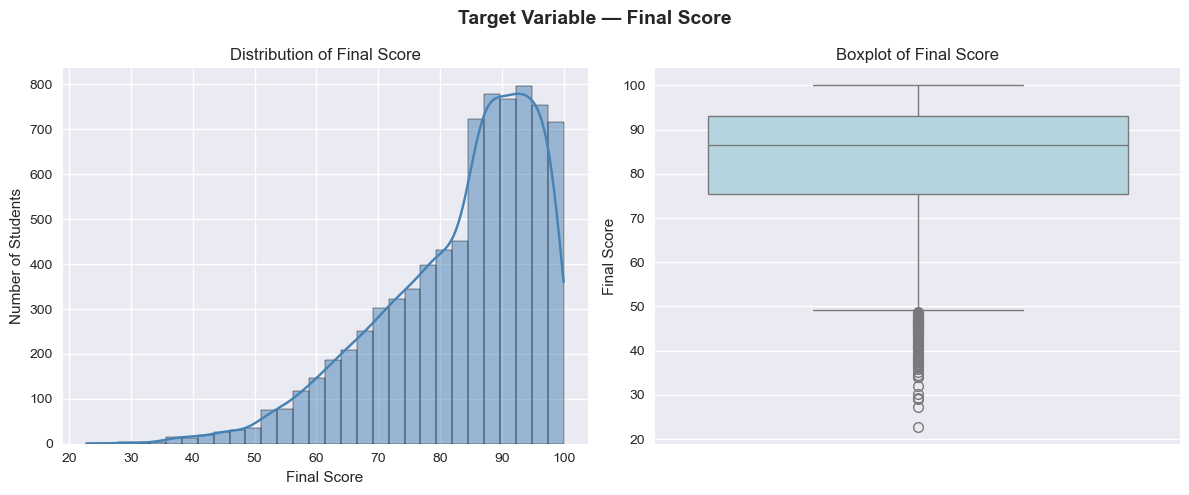

=== Final Score Statistics ===
Mean  : 83.21
Median: 86.51
Std   : 12.76
Min   : 22.81
Max   : 99.98


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_score['Final_Score'], bins=30, kde=True, 
             color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Final Score')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Number of Students')

sns.boxplot(y=df_score['Final_Score'], color='lightblue', ax=axes[1])
axes[1].set_title('Boxplot of Final Score')
axes[1].set_ylabel('Final Score')

plt.suptitle('Target Variable — Final Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/01_final_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Final Score Statistics ===")
print("Mean  :", round(df_score['Final_Score'].mean(), 2))
print("Median:", round(df_score['Final_Score'].median(), 2))
print("Std   :", round(df_score['Final_Score'].std(), 2))
print("Min   :", round(df_score['Final_Score'].min(), 2))
print("Max   :", round(df_score['Final_Score'].max(), 2))

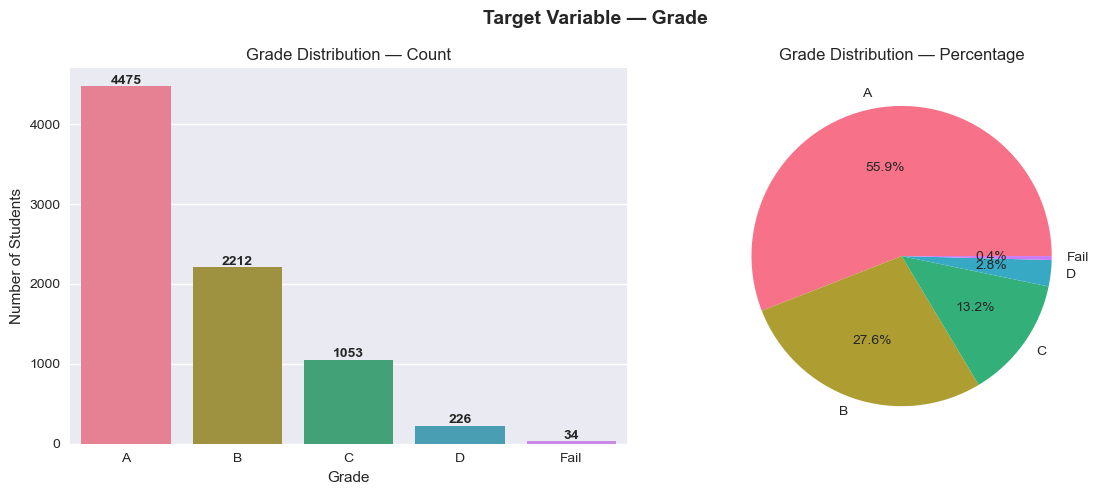

=== Grade Counts ===
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

grade_order = ['A', 'B', 'C', 'D', 'Fail']
grade_counts = df_grade['Grade'].value_counts().reindex(grade_order)

sns.barplot(x=grade_counts.index, y=grade_counts.values, 
            palette='husl', ax=axes[0])
axes[0].set_title('Grade Distribution — Count')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(grade_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(grade_counts.values, labels=grade_counts.index, 
            autopct='%1.1f%%', colors=sns.color_palette('husl', 5))
axes[1].set_title('Grade Distribution — Percentage')

plt.suptitle('Target Variable — Grade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/02_grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== Grade Counts ===")
print(grade_counts)

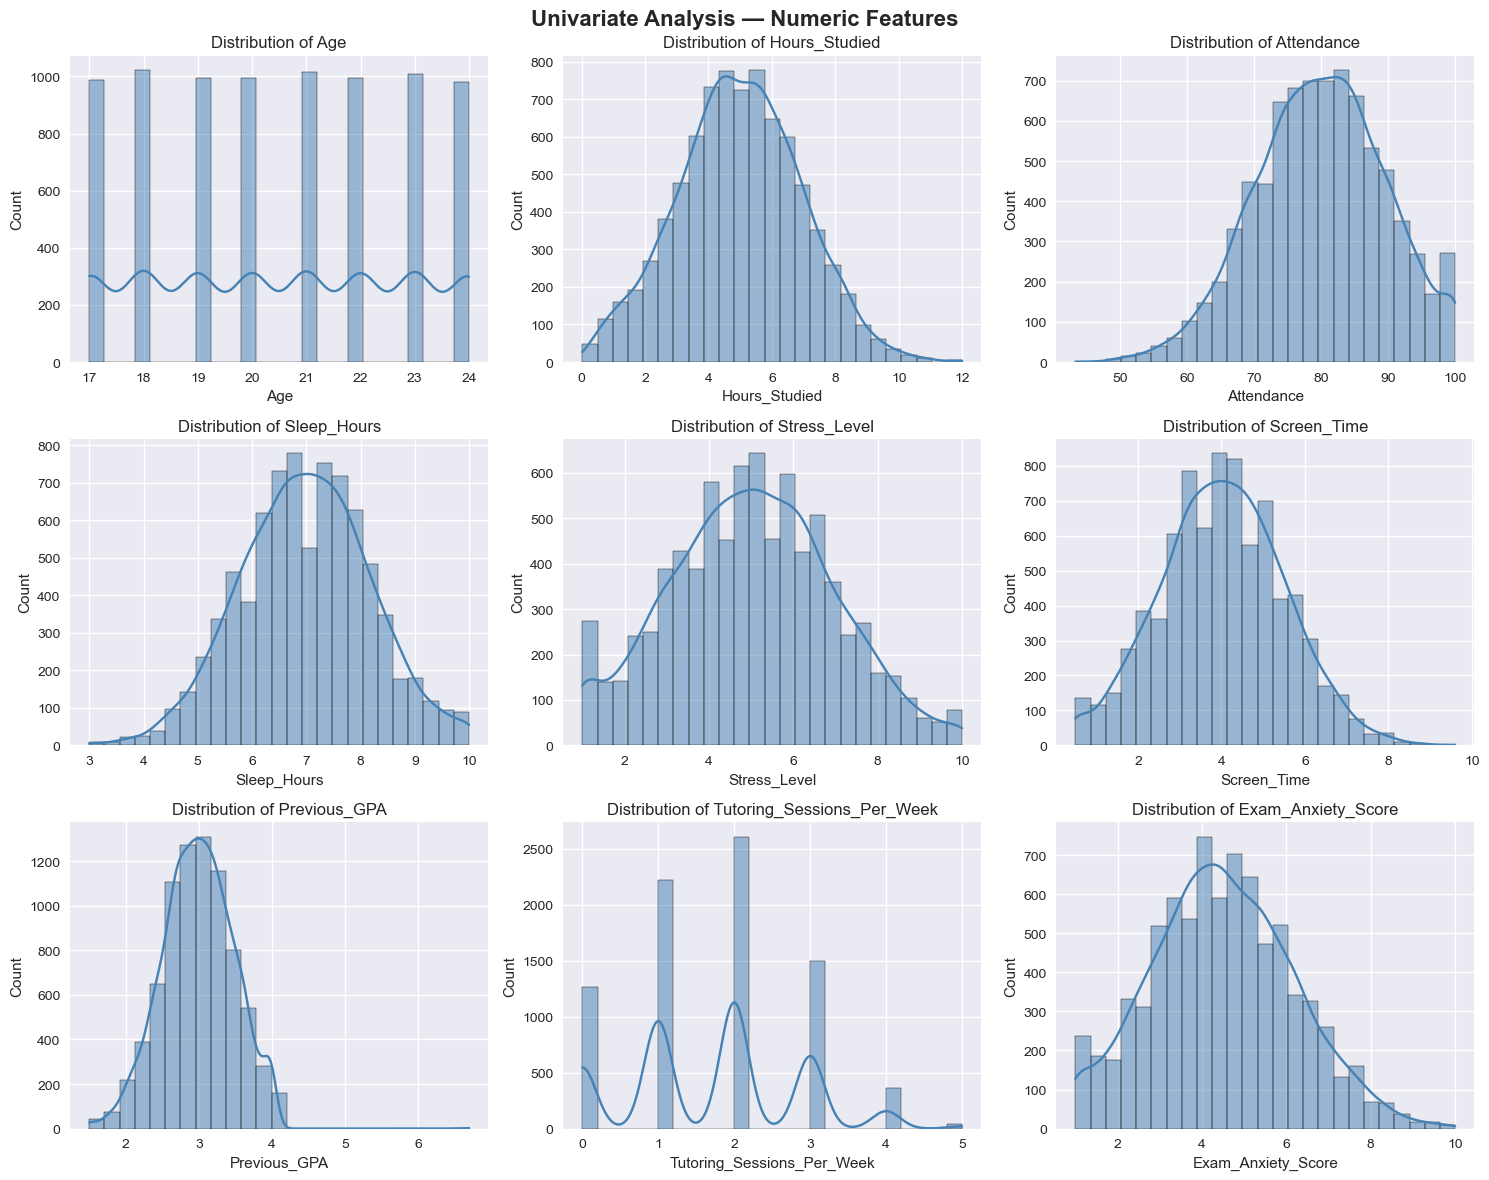

In [11]:
numeric_cols = ['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 
                'Stress_Level', 'Screen_Time', 'Previous_GPA', 
                'Tutoring_Sessions_Per_Week', 'Exam_Anxiety_Score']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_score[col], bins=25, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Univariate Analysis — Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/03_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

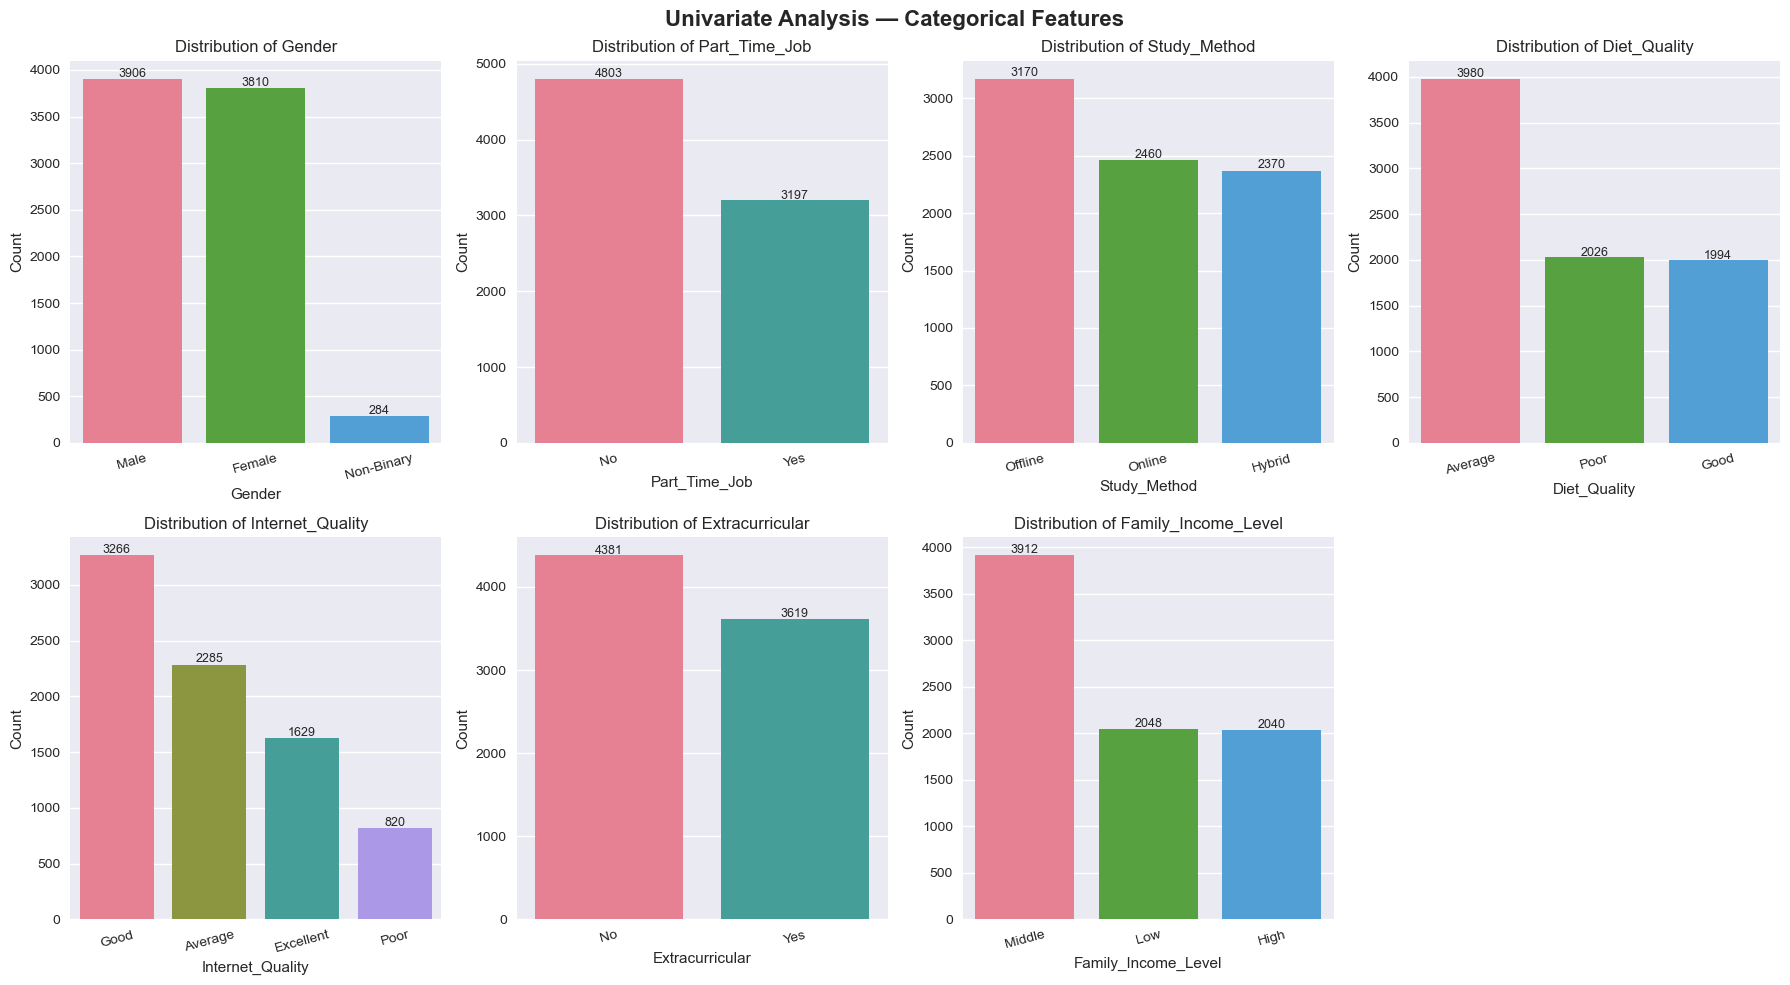

In [12]:
cat_cols = ['Gender', 'Part_Time_Job', 'Study_Method', 
            'Diet_Quality', 'Internet_Quality', 
            'Extracurricular', 'Family_Income_Level']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df_score[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 20, str(v), ha='center', fontsize=9)

axes[-1].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/04_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

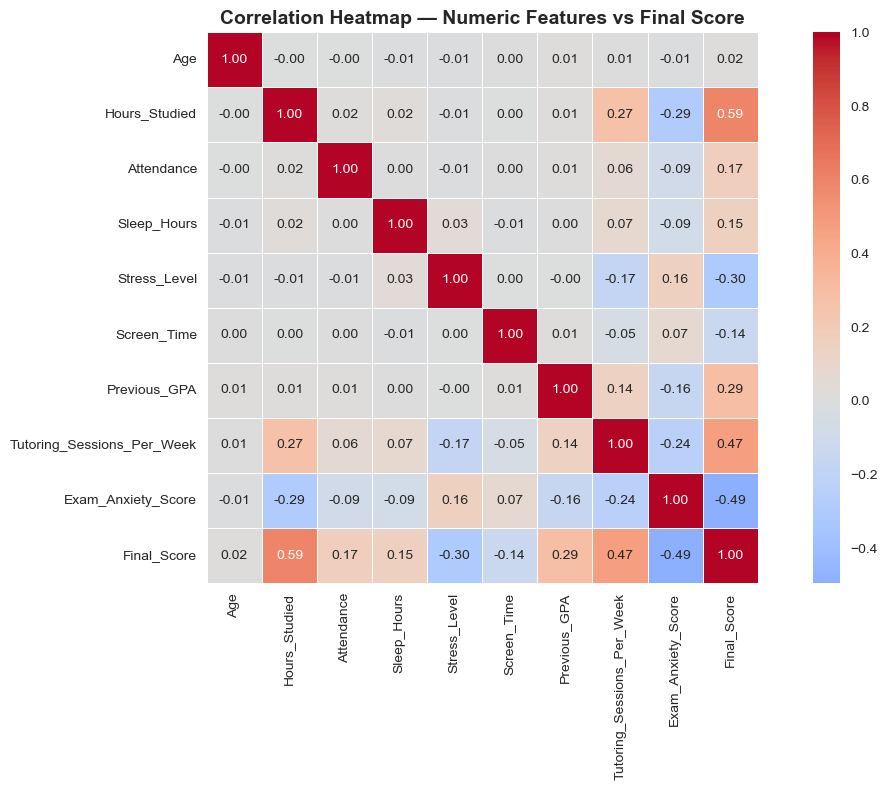

=== CORRELATION WITH FINAL SCORE (sorted) ===
Final_Score                   1.000000
Hours_Studied                 0.591355
Tutoring_Sessions_Per_Week    0.471524
Previous_GPA                  0.291002
Attendance                    0.168615
Sleep_Hours                   0.151673
Age                           0.017103
Screen_Time                  -0.135252
Stress_Level                 -0.296634
Exam_Anxiety_Score           -0.494940
Name: Final_Score, dtype: float64


In [13]:
# correlation heatmap
# Select only numeric columns for correlation
numeric_df = df_score.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — Numeric Features vs Final Score', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with Final Score specifically
print("=== CORRELATION WITH FINAL SCORE (sorted) ===")
print(correlation_matrix['Final_Score'].sort_values(ascending=False))

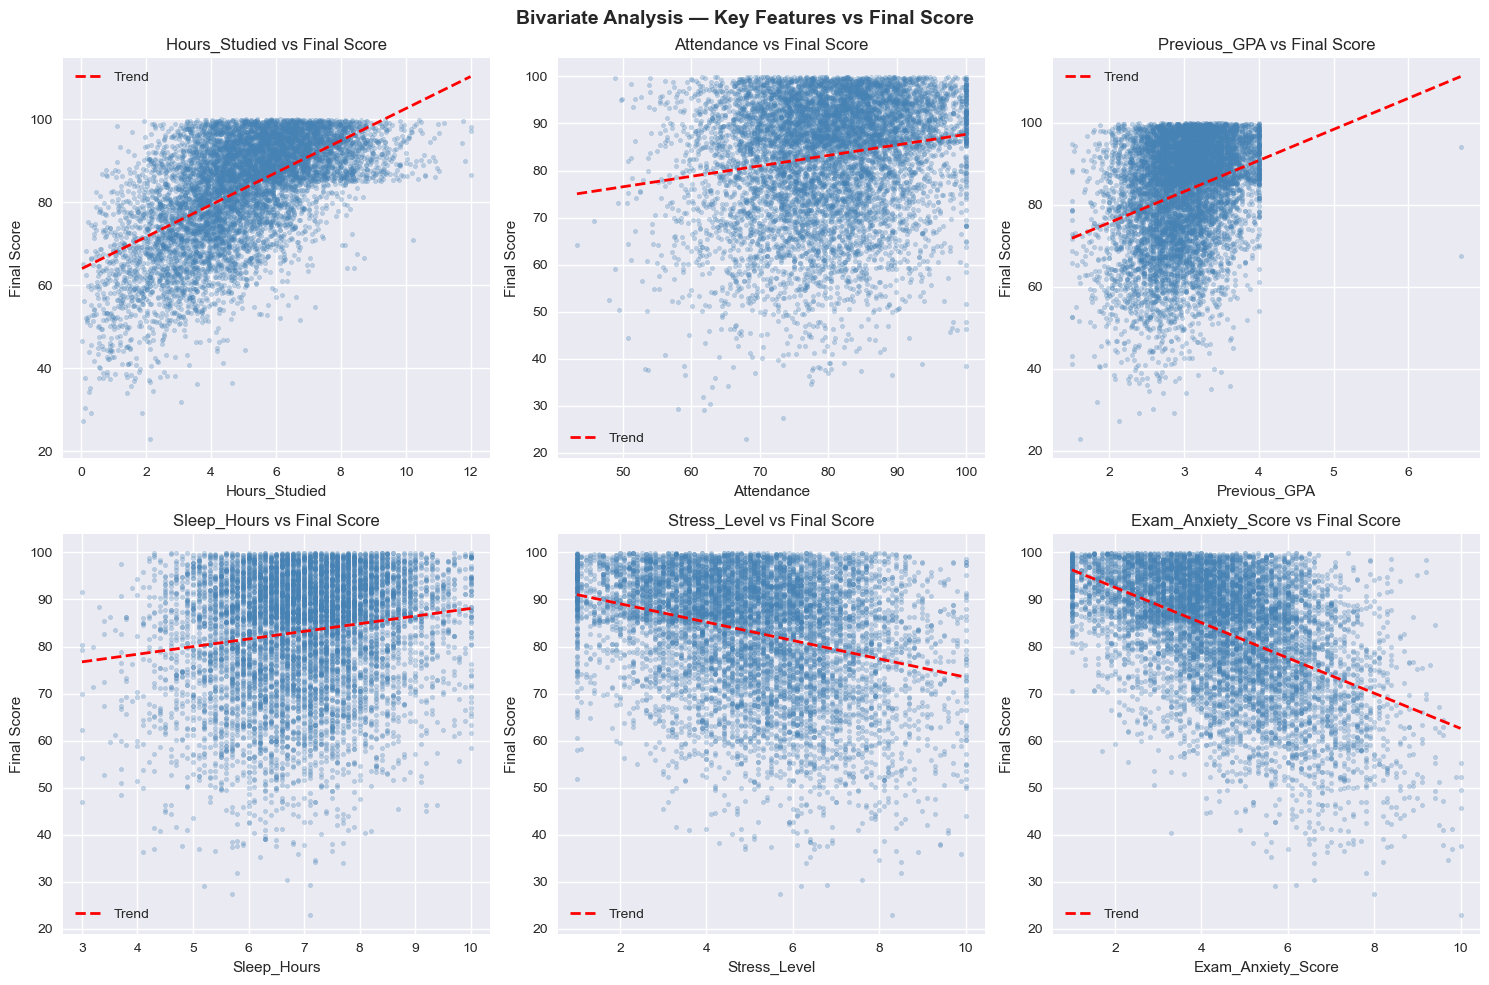

In [14]:
# top features versus final score

top_features = ['Hours_Studied', 'Attendance', 'Previous_GPA', 
                'Sleep_Hours', 'Stress_Level', 'Exam_Anxiety_Score']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df_score[col], df_score['Final_Score'], 
                   alpha=0.3, color='steelblue', s=10)
    # Add trend line
    z = np.polyfit(df_score[col], df_score['Final_Score'], 1)
    p = np.poly1d(z)
    axes[i].plot(sorted(df_score[col]), 
                p(sorted(df_score[col])), 
                "r--", linewidth=2, label='Trend')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Final Score')
    axes[i].set_title(f'{col} vs Final Score')
    axes[i].legend()

plt.suptitle('Bivariate Analysis — Key Features vs Final Score', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/06_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

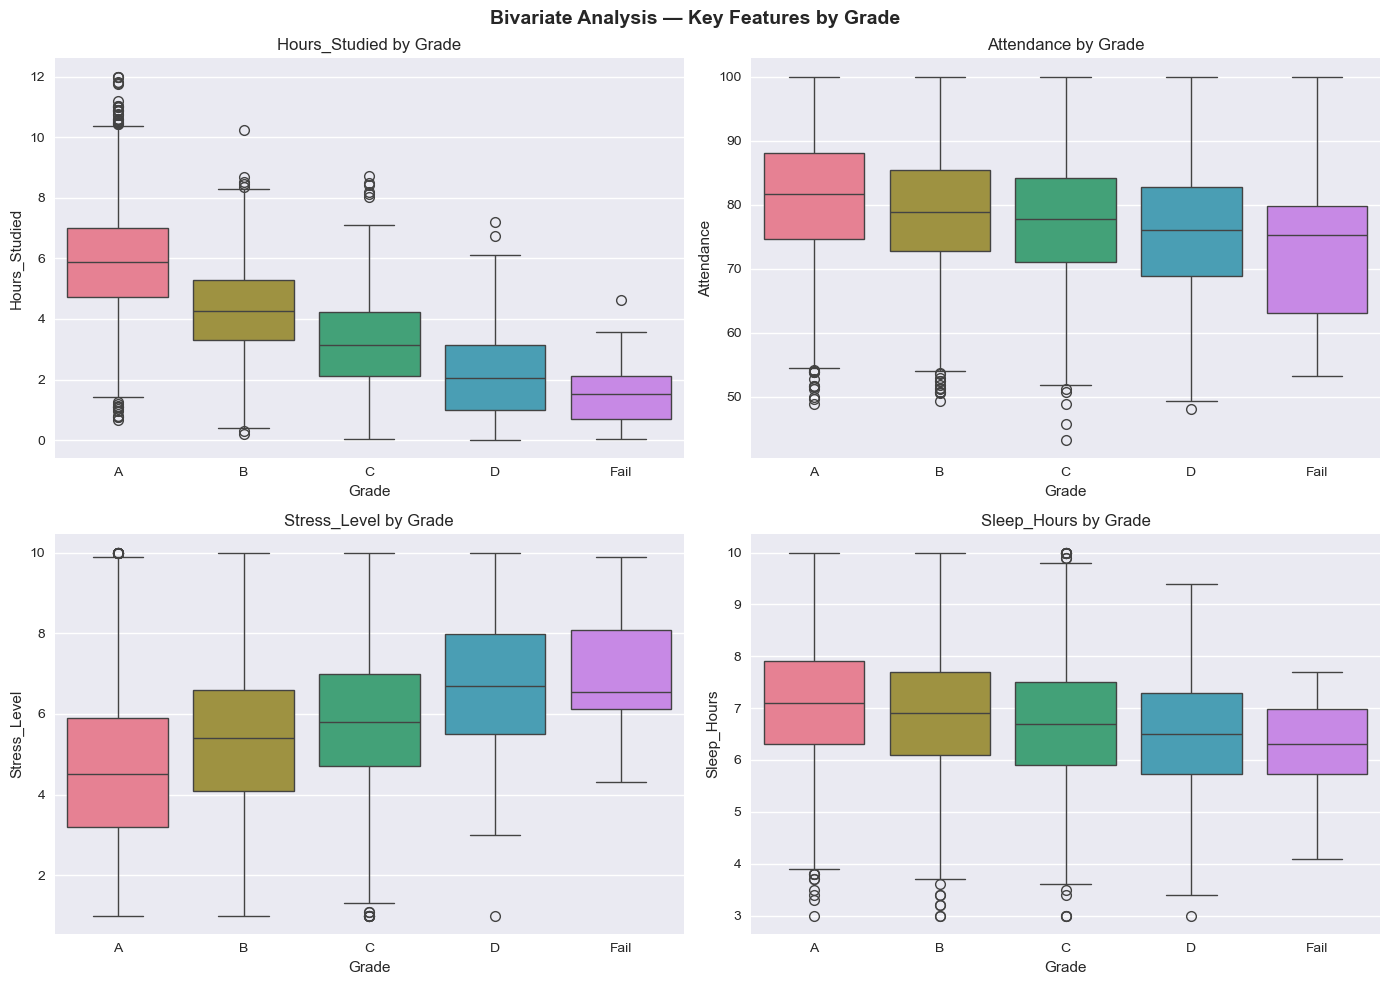

In [15]:
# grade versus key features

grade_order = ['A', 'B', 'C', 'D', 'Fail']
features_to_plot = ['Hours_Studied', 'Attendance', 
                    'Stress_Level', 'Sleep_Hours']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(data=df_grade, x='Grade', y=col, 
                order=grade_order, palette='husl', ax=axes[i])
    axes[i].set_title(f'{col} by Grade')
    axes[i].set_xlabel('Grade')
    axes[i].set_ylabel(col)

plt.suptitle('Bivariate Analysis — Key Features by Grade', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/07_grade_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

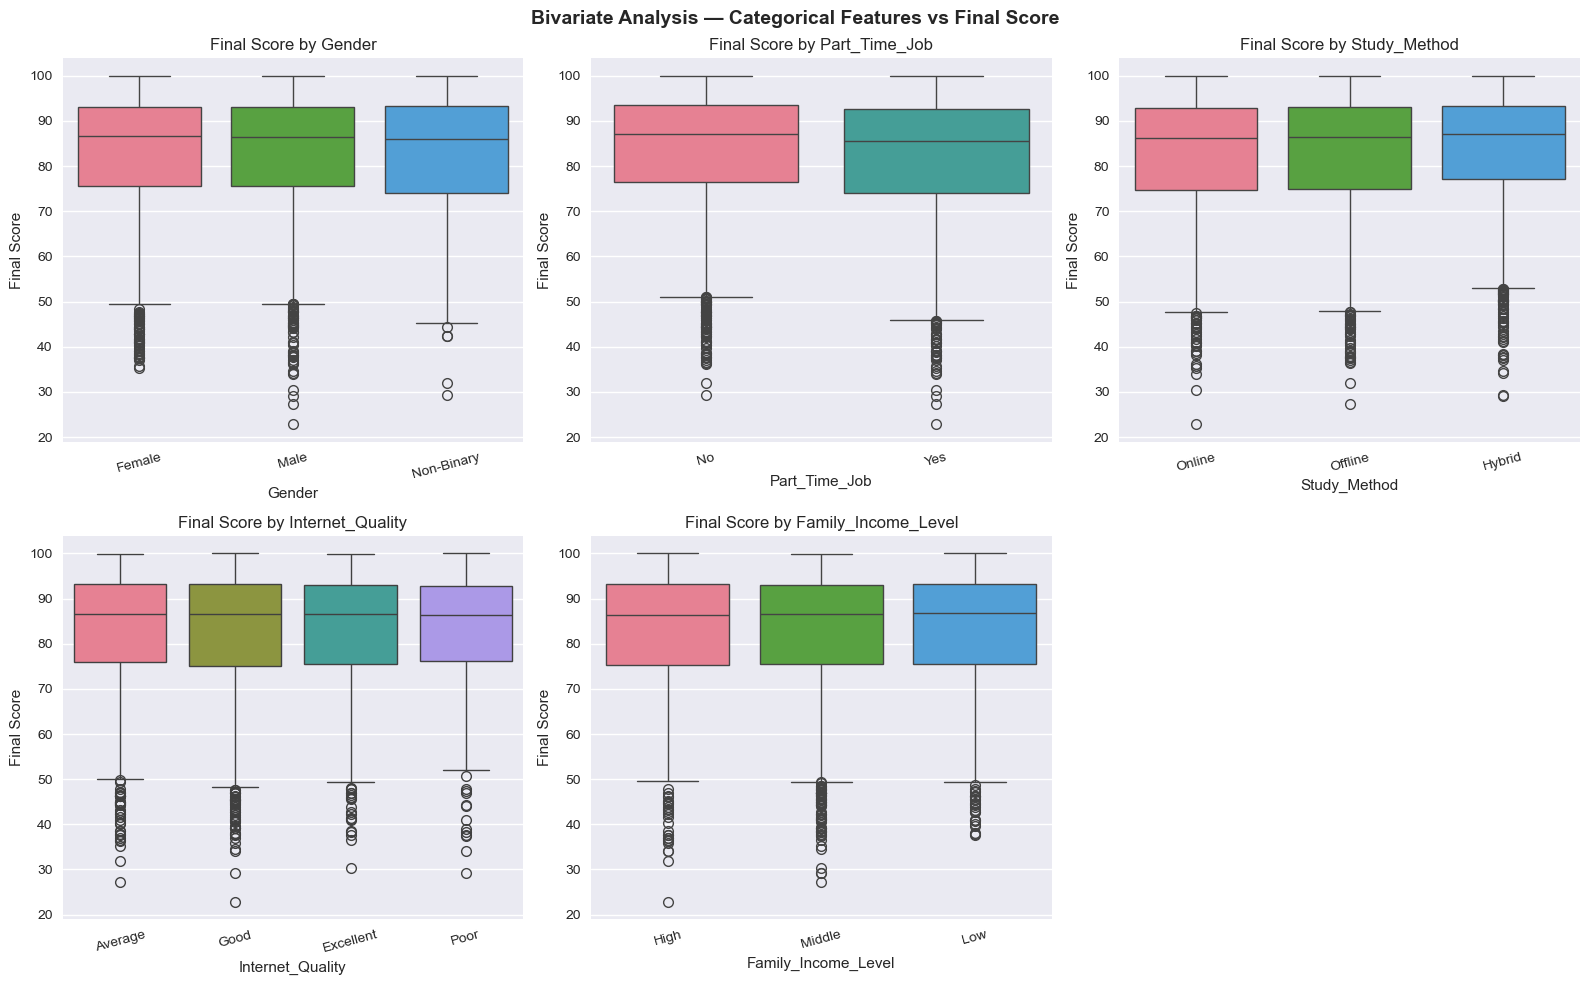

In [16]:
# category features versus final score
cat_cols = ['Gender', 'Part_Time_Job', 'Study_Method', 
            'Internet_Quality', 'Family_Income_Level']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df_score, x=col, y='Final_Score', 
                palette='husl', ax=axes[i])
    axes[i].set_title(f'Final Score by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Final Score')
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)

plt.suptitle('Bivariate Analysis — Categorical Features vs Final Score', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/08_categorical_vs_score.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Step 6 - Outlier Detection using IQR method
numeric_cols = ['Age', 'Hours_Studied', 'Attendance', 'Sleep_Hours',
                'Stress_Level', 'Screen_Time', 'Previous_GPA',
                'Tutoring_Sessions_Per_Week', 'Exam_Anxiety_Score', 'Final_Score']

print("=== OUTLIER DETECTION USING IQR METHOD ===\n")
outlier_summary = []

for col in numeric_cols:
    Q1 = df_score[col].quantile(0.25)
    Q3 = df_score[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outliers = df_score[(df_score[col] < lower_fence) | (df_score[col] > upper_fence)]
    outlier_count = len(outliers)
    outlier_pct = round((outlier_count / len(df_score)) * 100, 2)
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Fence': round(lower_fence, 2),
        'Upper Fence': round(upper_fence, 2),
        'Outlier Count': outlier_count,
        'Outlier %': outlier_pct
    })
    print(f"{col}:")
    print(f"  Q1={round(Q1,2)}, Q3={round(Q3,2)}, IQR={round(IQR,2)}")
    print(f"  Lower Fence={round(lower_fence,2)}, Upper Fence={round(upper_fence,2)}")
    print(f"  Outliers: {outlier_count} ({outlier_pct}%)\n")

import pandas as pd
outlier_df = pd.DataFrame(outlier_summary)
print("=== SUMMARY TABLE ===")
print(outlier_df[['Feature', 'Outlier Count', 'Outlier %']].to_string(index=False))

=== OUTLIER DETECTION USING IQR METHOD ===

Age:
  Q1=18.0, Q3=22.0, IQR=4.0
  Lower Fence=12.0, Upper Fence=28.0
  Outliers: 0 (0.0%)

Hours_Studied:
  Q1=3.68, Q3=6.31, IQR=2.63
  Lower Fence=-0.27, Upper Fence=10.26
  Outliers: 31 (0.39%)

Attendance:
  Q1=73.4, Q3=86.6, IQR=13.2
  Lower Fence=53.6, Upper Fence=106.4
  Outliers: 32 (0.4%)

Sleep_Hours:
  Q1=6.2, Q3=7.8, IQR=1.6
  Lower Fence=3.8, Upper Fence=10.2
  Outliers: 40 (0.5%)

Stress_Level:
  Q1=3.7, Q3=6.3, IQR=2.6
  Lower Fence=-0.2, Upper Fence=10.2
  Outliers: 0 (0.0%)

Screen_Time:
  Q1=3.0, Q3=5.0, IQR=2.0
  Lower Fence=0.0, Upper Fence=8.0
  Outliers: 27 (0.34%)

Previous_GPA:
  Q1=2.67, Q3=3.33, IQR=0.66
  Lower Fence=1.68, Upper Fence=4.32
  Outliers: 39 (0.49%)

Tutoring_Sessions_Per_Week:
  Q1=1.0, Q3=2.0, IQR=1.0
  Lower Fence=-0.5, Upper Fence=3.5
  Outliers: 405 (5.06%)

Exam_Anxiety_Score:
  Q1=3.3, Q3=5.6, IQR=2.3
  Lower Fence=-0.15, Upper Fence=9.05
  Outliers: 39 (0.49%)

Final_Score:
  Q1=75.51, Q3=93.08

In [19]:
# Step 7 - Feature Assessment
print("=== FEATURE ASSESSMENT ===\n")

# 1. Correlation with Final Score (already computed, reprinting cleanly)
numeric_df = df_score.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Final_Score'].drop('Final_Score')
correlations_abs = correlations.abs().sort_values(ascending=False)

print("--- Correlation with Final Score (Absolute Values) ---")
for feat, val in correlations_abs.items():
    direction = "+" if correlations[feat] > 0 else "-"
    strength = "STRONG" if val >= 0.4 else "MODERATE" if val >= 0.15 else "WEAK"
    print(f"  {feat:<30} r={direction}{round(val,3):<8} [{strength}]")

# 2. Variance of each numeric feature
print("\n--- Feature Variance (Low variance = less useful) ---")
variances = numeric_df.drop(columns=['Final_Score']).var().sort_values(ascending=False)
for feat, val in variances.items():
    flag = " ⚠️ LOW VARIANCE" if val < 0.5 else ""
    print(f"  {feat:<30} variance={round(val,3)}{flag}")

# 3. Categorical feature assessment
print("\n--- Categorical Feature Cardinality ---")
cat_cols = ['Gender', 'Part_Time_Job', 'Study_Method',
            'Diet_Quality', 'Internet_Quality',
            'Extracurricular', 'Family_Income_Level']
for col in cat_cols:
    unique_vals = df_score[col].nunique()
    print(f"  {col:<30} unique values={unique_vals}  categories={df_score[col].unique().tolist()}")

# 4. Features to potentially drop
print("\n--- FEATURE ASSESSMENT VERDICT ---")
print("DROP candidates (correlation < 0.02 with Final Score):")
weak = correlations_abs[correlations_abs < 0.02]
for feat, val in weak.items():
    print(f"  {feat} (r={round(val,3)})")
print("\nKEEP (all others — will be confirmed after feature engineering)")

=== FEATURE ASSESSMENT ===

--- Correlation with Final Score (Absolute Values) ---
  Hours_Studied                  r=+0.591    [STRONG]
  Exam_Anxiety_Score             r=-0.495    [STRONG]
  Tutoring_Sessions_Per_Week     r=+0.472    [STRONG]
  Stress_Level                   r=-0.297    [MODERATE]
  Previous_GPA                   r=+0.291    [MODERATE]
  Attendance                     r=+0.169    [MODERATE]
  Sleep_Hours                    r=+0.152    [MODERATE]
  Screen_Time                    r=-0.135    [WEAK]
  Age                            r=+0.017    [WEAK]

--- Feature Variance (Low variance = less useful) ---
  Attendance                     variance=93.25
  Age                            variance=5.226
  Hours_Studied                  variance=3.809
  Stress_Level                   variance=3.764
  Exam_Anxiety_Score             variance=2.841
  Screen_Time                    variance=2.196
  Sleep_Hours                    variance=1.423
  Tutoring_Sessions_Per_Week     var

In [20]:
# Step 8 - EDA Insights and Hypothesis Formation Summary
print("=" * 60)
print("STEP 8: EDA INSIGHTS AND HYPOTHESIS FORMATION")
print("=" * 60)

print("""
KEY INSIGHTS FROM EDA:
──────────────────────
INSIGHT 1 [STRONG POSITIVE PREDICTORS]
  Hours_Studied      r=+0.591  → Most powerful predictor
  Tutoring_Sessions  r=+0.472  → Academic support matters
  Previous_GPA       r=+0.291  → Past performance predicts future

INSIGHT 2 [STRONG NEGATIVE PREDICTORS]  
  Exam_Anxiety_Score r=-0.495  → Anxiety is academically costly
  Stress_Level       r=-0.297  → Stress reduces performance

INSIGHT 3 [WEAK PREDICTORS - kept for interaction effects]
  Sleep_Hours        r=+0.152
  Attendance         r=+0.169
  Screen_Time        r=-0.135

INSIGHT 4 [NEGLIGIBLE - drop candidate]
  Age                r=+0.017  → Age irrelevant within 17-24 range

INSIGHT 5 [CLASS IMBALANCE]
  Grade A = 55.9%, Fail = 0.4%
  → SMOTE required before model training

INSIGHT 6 [OUTLIERS]
  728 total outliers across all features (0.34% to 5.06%)
  → All retained as legitimate real-world cases
  → 115 Final Score outliers = at-risk students (core target)

INSIGHT 7 [CATEGORICAL PATTERNS]
  Gender  → No performance difference (fairness confirmed)
  Internet Quality → Poor internet slightly reduces scores
  Study Method → Hybrid performs marginally best
  Family Income → High income marginally outperforms

HYPOTHESES FORMED:
──────────────────
H1: CONFIRMED by EDA
  Study hours, stress, attendance and prior GPA
  all correlate significantly with Final Score

H2: PARTIALLY SUPPORTED
  Internet quality shows modest score differences
  Full confirmation pending Cameroon feature engineering

H3: TO BE TESTED
  Random Forest expected to outperform Logistic 
  Regression and Decision Tree based on literature
  → Will be confirmed during model training
""")

print("EDA COMPLETE. Ready for Feature Engineering.")
print("Dataset shape before engineering:", df_score.shape)
print("Features to engineer: 10 Cameroon-specific variables")
print("Expected shape after engineering:", 
      (df_score.shape[0], df_score.shape[1] + 10))

STEP 8: EDA INSIGHTS AND HYPOTHESIS FORMATION

KEY INSIGHTS FROM EDA:
──────────────────────
INSIGHT 1 [STRONG POSITIVE PREDICTORS]
  Hours_Studied      r=+0.591  → Most powerful predictor
  Tutoring_Sessions  r=+0.472  → Academic support matters
  Previous_GPA       r=+0.291  → Past performance predicts future

INSIGHT 2 [STRONG NEGATIVE PREDICTORS]  
  Exam_Anxiety_Score r=-0.495  → Anxiety is academically costly
  Stress_Level       r=-0.297  → Stress reduces performance

INSIGHT 3 [WEAK PREDICTORS - kept for interaction effects]
  Sleep_Hours        r=+0.152
  Attendance         r=+0.169
  Screen_Time        r=-0.135

INSIGHT 4 [NEGLIGIBLE - drop candidate]
  Age                r=+0.017  → Age irrelevant within 17-24 range

INSIGHT 5 [CLASS IMBALANCE]
  Grade A = 55.9%, Fail = 0.4%
  → SMOTE required before model training

INSIGHT 6 [OUTLIERS]
  728 total outliers across all features (0.34% to 5.06%)
  → All retained as legitimate real-world cases
  → 115 Final Score outliers = at-

In [21]:
# feature engineering

In [22]:
# ============================================================
# FEATURE ENGINEERING — CAMEROON-SPECIFIC VARIABLES
# ============================================================
np.random.seed(42)  # For reproducibility
n = len(df_score)

print("Adding Cameroon-specific features...\n")

# ── FEATURE 1: Electricity_Availability ──────────────────────
# Continuous 0-1: proportion of time student has electricity
# Cameroon reality: frequent power outages (ENEO load shedding)
# Mean ~0.55, correlated with Family_Income_Level
income_map = {'Low': 0.0, 'Middle': 0.15, 'High': 0.30}
income_boost = df_score['Family_Income_Level'].map(income_map)
electricity_base = np.random.beta(a=2, b=2, size=n)
df_score['Electricity_Availability'] = np.clip(
    electricity_base + income_boost * 0.3, 0, 1
).round(2)

print("✅ Feature 1: Electricity_Availability")
print(f"   Mean: {df_score['Electricity_Availability'].mean():.3f}")
print(f"   Std:  {df_score['Electricity_Availability'].std():.3f}")
print(f"   Min:  {df_score['Electricity_Availability'].min():.3f}")
print(f"   Max:  {df_score['Electricity_Availability'].max():.3f}\n")

# ── FEATURE 2: Internet_Accessibility ────────────────────────
# Ordinal 0=None, 1=Limited, 2=Good
# Correlated with existing Internet_Quality column
internet_quality_map = {'Poor': 0, 'Average': 1, 'Good': 1, 'Excellent': 2}
internet_base = df_score['Internet_Quality'].map(internet_quality_map)
noise = np.random.randint(-1, 2, size=n)
df_score['Internet_Accessibility'] = np.clip(
    internet_base + noise, 0, 2
).astype(int)

print("✅ Feature 2: Internet_Accessibility (0=None, 1=Limited, 2=Good)")
print(df_score['Internet_Accessibility'].value_counts().sort_index())
print()

# ── FEATURE 3: Peer_Influence ─────────────────────────────────
# Categorical: Negative, Neutral, Positive
# Correlated with Attendance and Hours_Studied
# Higher study hours + attendance → more likely positive peer group
combined = (df_score['Hours_Studied'] / 12 + 
            df_score['Attendance'] / 100) / 2

def assign_peer(score):
    if score < 0.35:
        return np.random.choice(['Negative', 'Neutral'], p=[0.6, 0.4])
    elif score < 0.60:
        return np.random.choice(['Negative', 'Neutral', 'Positive'], 
                                p=[0.2, 0.5, 0.3])
    else:
        return np.random.choice(['Neutral', 'Positive'], p=[0.3, 0.7])

df_score['Peer_Influence'] = combined.apply(assign_peer)

print("✅ Feature 3: Peer_Influence")
print(df_score['Peer_Influence'].value_counts())
print()

# ── FEATURE 4: Community_Beliefs ─────────────────────────────
# Ordinal 1-5: degree community supports education
# Independent variable, normally distributed
df_score['Community_Beliefs'] = np.clip(
    np.random.normal(loc=3.0, scale=1.0, size=n), 1, 5
).round(1)

print("✅ Feature 4: Community_Beliefs (1-5 scale)")
print(f"   Mean: {df_score['Community_Beliefs'].mean():.3f}")
print(f"   Std:  {df_score['Community_Beliefs'].std():.3f}\n")

# ── FEATURE 5: Family_Support ─────────────────────────────────
# Ordinal 1-5: family academic and emotional support
# Inversely correlated with Stress_Level
stress_normalised = df_score['Stress_Level'] / 10
family_base = np.random.normal(loc=3.5, scale=0.8, size=n)
df_score['Family_Support'] = np.clip(
    family_base - stress_normalised * 1.5, 1, 5
).round(1)

print("✅ Feature 5: Family_Support (1-5 scale)")
print(f"   Mean: {df_score['Family_Support'].mean():.3f}")
print(f"   Std:  {df_score['Family_Support'].std():.3f}\n")

# ── FEATURE 6: Home_Study_Environment ────────────────────────
# Ordinal 1-5: suitability of home for studying
# Correlated with Electricity_Availability and Family_Income_Level
income_map2 = {'Low': 0.0, 'Middle': 0.3, 'High': 0.6}
income_boost2 = df_score['Family_Income_Level'].map(income_map2)
env_base = np.random.normal(loc=2.8, scale=0.9, size=n)
df_score['Home_Study_Environment'] = np.clip(
    env_base + df_score['Electricity_Availability'] * 1.2 + income_boost2, 
    1, 5
).round(1)

print("✅ Feature 6: Home_Study_Environment (1-5 scale)")
print(f"   Mean: {df_score['Home_Study_Environment'].mean():.3f}")
print(f"   Std:  {df_score['Home_Study_Environment'].std():.3f}\n")

# ── FEATURE 7: Motivation_Level ───────────────────────────────
# Ordinal 1-5: intrinsic academic motivation
# Positively correlated with Hours_Studied
# Negatively correlated with Stress_Level
hours_norm = df_score['Hours_Studied'] / 12
stress_norm = df_score['Stress_Level'] / 10
motivation_base = np.random.normal(loc=3.0, scale=0.8, size=n)
df_score['Motivation_Level'] = np.clip(
    motivation_base + hours_norm * 2.0 - stress_norm * 1.5, 
    1, 5
).round(1)

print("✅ Feature 7: Motivation_Level (1-5 scale)")
print(f"   Mean: {df_score['Motivation_Level'].mean():.3f}")
print(f"   Std:  {df_score['Motivation_Level'].std():.3f}\n")

# ── FEATURE 8: Lecture_Quality ────────────────────────────────
# Ordinal 1-5: perceived quality of instruction
# Independent — varies across institutions and lecturers
df_score['Lecture_Quality'] = np.clip(
    np.random.normal(loc=3.0, scale=1.0, size=n), 1, 5
).round(1)

print("✅ Feature 8: Lecture_Quality (1-5 scale)")
print(f"   Mean: {df_score['Lecture_Quality'].mean():.3f}")
print(f"   Std:  {df_score['Lecture_Quality'].std():.3f}\n")

# ── FEATURE 9: Physical_Health ────────────────────────────────
# Ordinal 1-5: general physical health status
# Correlated with Sleep_Hours and Diet_Quality
sleep_norm = df_score['Sleep_Hours'] / 10
diet_map = {'Poor': 0.0, 'Average': 0.3, 'Good': 0.6}
diet_boost = df_score['Diet_Quality'].map(diet_map)
health_base = np.random.normal(loc=3.0, scale=0.8, size=n)
df_score['Physical_Health'] = np.clip(
    health_base + sleep_norm * 1.5 + diet_boost, 
    1, 5
).round(1)

print("✅ Feature 9: Physical_Health (1-5 scale)")
print(f"   Mean: {df_score['Physical_Health'].mean():.3f}")
print(f"   Std:  {df_score['Physical_Health'].std():.3f}\n")

# ── FEATURE 10: Psychological_State ──────────────────────────
# Ordinal 1-5: general psychological wellbeing
# Inversely correlated with Stress_Level and Exam_Anxiety_Score
# Positively correlated with Sleep_Hours and Family_Support
stress_norm2 = df_score['Stress_Level'] / 10
anxiety_norm = df_score['Exam_Anxiety_Score'] / 10
sleep_norm2 = df_score['Sleep_Hours'] / 10
support_norm = df_score['Family_Support'] / 5
psych_base = np.random.normal(loc=3.0, scale=0.7, size=n)
df_score['Psychological_State'] = np.clip(
    psych_base 
    - stress_norm2 * 1.5 
    - anxiety_norm * 1.5 
    + sleep_norm2 * 1.0 
    + support_norm * 1.0,
    1, 5
).round(1)

print("✅ Feature 10: Psychological_State (1-5 scale)")
print(f"   Mean: {df_score['Psychological_State'].mean():.3f}")
print(f"   Std:  {df_score['Psychological_State'].std():.3f}\n")

# ── FINAL VERIFICATION ────────────────────────────────────────
print("=" * 55)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 55)
print(f"Original shape:     (8000, 17)")
print(f"New shape:          {df_score.shape}")
print(f"Features added:     {df_score.shape[1] - 17}")
print(f"\nNew columns added:")
new_cols = ['Electricity_Availability', 'Internet_Accessibility',
            'Peer_Influence', 'Community_Beliefs', 'Family_Support',
            'Home_Study_Environment', 'Motivation_Level', 
            'Lecture_Quality', 'Physical_Health', 'Psychological_State']
for col in new_cols:
    print(f"  + {col}")
print(f"\nAll columns ({df_score.shape[1]} total):")
print(df_score.columns.tolist())

Adding Cameroon-specific features...

✅ Feature 1: Electricity_Availability
   Mean: 0.550
   Std:  0.223
   Min:  0.000
   Max:  1.000

✅ Feature 2: Internet_Accessibility (0=None, 1=Limited, 2=Good)
Internet_Accessibility
0    2424
1    2634
2    2942
Name: count, dtype: int64

✅ Feature 3: Peer_Influence
Peer_Influence
Positive    4157
Neutral     3081
Negative     762
Name: count, dtype: int64

✅ Feature 4: Community_Beliefs (1-5 scale)
   Mean: 3.009
   Std:  0.957

✅ Feature 5: Family_Support (1-5 scale)
   Mean: 2.744
   Std:  0.826

✅ Feature 6: Home_Study_Environment (1-5 scale)
   Mean: 3.694
   Std:  0.885

✅ Feature 7: Motivation_Level (1-5 scale)
   Mean: 3.081
   Std:  0.885

✅ Feature 8: Lecture_Quality (1-5 scale)
   Mean: 3.005
   Std:  0.966

✅ Feature 9: Physical_Health (1-5 scale)
   Mean: 4.244
   Std:  0.684

✅ Feature 10: Psychological_State (1-5 scale)
   Mean: 2.829
   Std:  0.843

FEATURE ENGINEERING COMPLETE
Original shape:     (8000, 17)
New shape:          

In [23]:
# Apply same feature engineering to df_grade
# Using same random seed for consistency
np.random.seed(42)
n = len(df_grade)

# Feature 1
income_map = {'Low': 0.0, 'Middle': 0.15, 'High': 0.30}
income_boost = df_grade['Family_Income_Level'].map(income_map)
electricity_base = np.random.beta(a=2, b=2, size=n)
df_grade['Electricity_Availability'] = np.clip(
    electricity_base + income_boost * 0.3, 0, 1).round(2)

# Feature 2
internet_quality_map = {'Poor': 0, 'Average': 1, 'Good': 1, 'Excellent': 2}
internet_base = df_grade['Internet_Quality'].map(internet_quality_map)
noise = np.random.randint(-1, 2, size=n)
df_grade['Internet_Accessibility'] = np.clip(
    internet_base + noise, 0, 2).astype(int)

# Feature 3
combined = (df_grade['Hours_Studied'] / 12 +
            df_grade['Attendance'] / 100) / 2
df_grade['Peer_Influence'] = combined.apply(assign_peer)

# Feature 4
df_grade['Community_Beliefs'] = np.clip(
    np.random.normal(loc=3.0, scale=1.0, size=n), 1, 5).round(1)

# Feature 5
stress_normalised = df_grade['Stress_Level'] / 10
family_base = np.random.normal(loc=3.5, scale=0.8, size=n)
df_grade['Family_Support'] = np.clip(
    family_base - stress_normalised * 1.5, 1, 5).round(1)

# Feature 6
income_map2 = {'Low': 0.0, 'Middle': 0.3, 'High': 0.6}
income_boost2 = df_grade['Family_Income_Level'].map(income_map2)
env_base = np.random.normal(loc=2.8, scale=0.9, size=n)
df_grade['Home_Study_Environment'] = np.clip(
    env_base + df_grade['Electricity_Availability'] * 1.2 + income_boost2,
    1, 5).round(1)

# Feature 7
hours_norm = df_grade['Hours_Studied'] / 12
stress_norm = df_grade['Stress_Level'] / 10
motivation_base = np.random.normal(loc=3.0, scale=0.8, size=n)
df_grade['Motivation_Level'] = np.clip(
    motivation_base + hours_norm * 2.0 - stress_norm * 1.5,
    1, 5).round(1)

# Feature 8
df_grade['Lecture_Quality'] = np.clip(
    np.random.normal(loc=3.0, scale=1.0, size=n), 1, 5).round(1)

# Feature 9
sleep_norm = df_grade['Sleep_Hours'] / 10
diet_map = {'Poor': 0.0, 'Average': 0.3, 'Good': 0.6}
diet_boost = df_grade['Diet_Quality'].map(diet_map)
health_base = np.random.normal(loc=3.0, scale=0.8, size=n)
df_grade['Physical_Health'] = np.clip(
    health_base + sleep_norm * 1.5 + diet_boost,
    1, 5).round(1)

# Feature 10
stress_norm2 = df_grade['Stress_Level'] / 10
anxiety_norm = df_grade['Exam_Anxiety_Score'] / 10
sleep_norm2 = df_grade['Sleep_Hours'] / 10
support_norm = df_grade['Family_Support'] / 5
psych_base = np.random.normal(loc=3.0, scale=0.7, size=n)
df_grade['Psychological_State'] = np.clip(
    psych_base
    - stress_norm2 * 1.5
    - anxiety_norm * 1.5
    + sleep_norm2 * 1.0
    + support_norm * 1.0,
    1, 5).round(1)

print("✅ Feature engineering applied to df_grade")
print(f"df_grade shape: {df_grade.shape}")
print(f"\ndf_grade columns ({df_grade.shape[1]} total):")
print(df_grade.columns.tolist())
print(f"\ndf_grade target distribution:")
print(df_grade['Grade'].value_counts())

✅ Feature engineering applied to df_grade
df_grade shape: (8000, 27)

df_grade columns (27 total):
['Age', 'Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Grade', 'Electricity_Availability', 'Internet_Accessibility', 'Peer_Influence', 'Community_Beliefs', 'Family_Support', 'Home_Study_Environment', 'Motivation_Level', 'Lecture_Quality', 'Physical_Health', 'Psychological_State']

df_grade target distribution:
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64


In [24]:
# ============================================================
# FIX: Rescale Previous_GPA to University of Buea scale (0-4)
# ============================================================

print("=== BEFORE FIX ===")
print(f"df_score Previous_GPA - Min: {df_score['Previous_GPA'].min()}, Max: {df_score['Previous_GPA'].max()}, Mean: {df_score['Previous_GPA'].mean():.3f}")
print(f"df_grade Previous_GPA - Min: {df_grade['Previous_GPA'].min()}, Max: {df_grade['Previous_GPA'].max()}, Mean: {df_grade['Previous_GPA'].mean():.3f}")

# Rescale: divide by original max (6.7) then multiply by 4
original_max = df_score['Previous_GPA'].max()  # 6.7

df_score['Previous_GPA'] = (df_score['Previous_GPA'] / original_max * 4).round(2)
df_grade['Previous_GPA'] = (df_grade['Previous_GPA'] / original_max * 4).round(2)

print("\n=== AFTER FIX ===")
print(f"df_score Previous_GPA - Min: {df_score['Previous_GPA'].min()}, Max: {df_score['Previous_GPA'].max()}, Mean: {df_score['Previous_GPA'].mean():.3f}")
print(f"df_grade Previous_GPA - Min: {df_grade['Previous_GPA'].min()}, Max: {df_grade['Previous_GPA'].max()}, Mean: {df_grade['Previous_GPA'].mean():.3f}")

print("\n=== SAMPLE VALUES ===")
print(df_score['Previous_GPA'].describe().round(3))

=== BEFORE FIX ===
df_score Previous_GPA - Min: 1.5, Max: 6.7, Mean: 2.992
df_grade Previous_GPA - Min: 1.5, Max: 6.7, Mean: 2.992

=== AFTER FIX ===
df_score Previous_GPA - Min: 0.9, Max: 4.0, Mean: 1.787
df_grade Previous_GPA - Min: 0.9, Max: 4.0, Mean: 1.787

=== SAMPLE VALUES ===
count    8000.000
mean        1.787
std         0.292
min         0.900
25%         1.590
50%         1.790
75%         1.990
max         4.000
Name: Previous_GPA, dtype: float64


In [25]:
# ============================================================
# FIX: Adjust Age range to reflect Cameroonian university reality
# Current range: 17-24
# Cameroonian reality: 17-30 (late entries, GCE repeats, 
# financial delays common)
# ============================================================

print("=== BEFORE FIX ===")
print(f"df_score Age - Min: {df_score['Age'].min()}, Max: {df_score['Age'].max()}, Mean: {df_score['Age'].mean():.3f}")
print(f"df_grade Age - Min: {df_grade['Age'].min()}, Max: {df_grade['Age'].max()}, Mean: {df_grade['Age'].mean():.3f}")

# Rescale age from 17-24 range to 17-30 range
# Formula: new_age = 17 + (old_age - 17) / (24 - 17) * (30 - 17)
df_score['Age'] = (17 + (df_score['Age'] - 17) / (24 - 17) * (30 - 17)).round(0).astype(int)
df_grade['Age'] = (17 + (df_grade['Age'] - 17) / (24 - 17) * (30 - 17)).round(0).astype(int)

print("\n=== AFTER FIX ===")
print(f"df_score Age - Min: {df_score['Age'].min()}, Max: {df_score['Age'].max()}, Mean: {df_score['Age'].mean():.3f}")
print(f"df_grade Age - Min: {df_grade['Age'].min()}, Max: {df_grade['Age'].max()}, Mean: {df_grade['Age'].mean():.3f}")

print("\n=== AGE DISTRIBUTION AFTER FIX ===")
print(df_score['Age'].value_counts().sort_index())

=== BEFORE FIX ===
df_score Age - Min: 17, Max: 24, Mean: 20.494
df_grade Age - Min: 17, Max: 24, Mean: 20.494

=== AFTER FIX ===
df_score Age - Min: 17, Max: 30, Mean: 23.489
df_grade Age - Min: 17, Max: 30, Mean: 23.489

=== AGE DISTRIBUTION AFTER FIX ===
Age
17     988
19    1022
21     994
23     996
24    1016
26     993
28    1009
30     982
Name: count, dtype: int64


In [26]:
# FIX: Age distribution has gaps - regenerate properly
np.random.seed(42)

# Generate realistic Cameroonian university age distribution
# Most students 17-24, fewer older students (late entry/repeaters)
age_probs = {
    17: 0.08, 18: 0.12, 19: 0.13, 20: 0.13,
    21: 0.12, 22: 0.10, 23: 0.09, 24: 0.08,
    25: 0.06, 26: 0.04, 27: 0.02, 28: 0.02,
    29: 0.01, 30: 0.00
}

ages = list(age_probs.keys())
probs = list(age_probs.values())

df_score['Age'] = np.random.choice(ages, size=len(df_score), p=probs)
df_grade['Age'] = np.random.choice(ages, size=len(df_grade), p=probs)

print("=== FIXED AGE DISTRIBUTION ===")
print(df_score['Age'].value_counts().sort_index())
print(f"\nMin: {df_score['Age'].min()}, Max: {df_score['Age'].max()}")
print(f"Mean: {df_score['Age'].mean():.2f}")

=== FIXED AGE DISTRIBUTION ===
Age
17     676
18     976
19    1033
20    1065
21     946
22     831
23     676
24     620
25     476
26     310
27     175
28     145
29      71
Name: count, dtype: int64

Min: 17, Max: 29
Mean: 21.17


In [27]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Step 1: Drop Age and separate features from target
# We work with df_grade for classification (predicting A/B/C/D/Fail)

df_model = df_grade.copy()
df_model = df_model.drop(columns=['Age'])

# Separate features (X) and target (y)
X = df_model.drop(columns=['Grade'])
y = df_model['Grade']

print("=== STEP 1: DROP AGE & SEPARATE FEATURES/TARGET ===")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y):   {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nFeature columns ({X.shape[1]} total):")
print(X.columns.tolist())

=== STEP 1: DROP AGE & SEPARATE FEATURES/TARGET ===
Features shape (X): (8000, 25)
Target shape (y):   (8000,)

Target distribution:
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64

Feature columns (25 total):
['Gender', 'Hours_Studied', 'Attendance', 'Sleep_Hours', 'Stress_Level', 'Screen_Time', 'Previous_GPA', 'Part_Time_Job', 'Study_Method', 'Diet_Quality', 'Internet_Quality', 'Extracurricular', 'Tutoring_Sessions_Per_Week', 'Family_Income_Level', 'Exam_Anxiety_Score', 'Electricity_Availability', 'Internet_Accessibility', 'Peer_Influence', 'Community_Beliefs', 'Family_Support', 'Home_Study_Environment', 'Motivation_Level', 'Lecture_Quality', 'Physical_Health', 'Psychological_State']


In [28]:
# Save engineered datasets to CSV
df_score.to_csv('../data/df_score_engineered.csv', index=False)
df_grade.to_csv('../data/df_grade_engineered.csv', index=False)

print("✅ Datasets saved successfully!")
print(f"df_score saved: {df_score.shape}")
print(f"df_grade saved: {df_grade.shape}")

✅ Datasets saved successfully!
df_score saved: (8000, 27)
df_grade saved: (8000, 27)


In [29]:
# ============================================================
# PREPROCESSING — STEPS 2 TO 6
# Continuing from Step 1
# ============================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ── STEP 2: ENCODE CATEGORICAL VARIABLES ─────────────────────

# --- Binary Encoding ---
binary_map = {'No': 0, 'Yes': 1}
X['Part_Time_Job']   = X['Part_Time_Job'].map(binary_map)
X['Extracurricular'] = X['Extracurricular'].map(binary_map)
print("=== STEP 2A: BINARY ENCODING ===")
print("✅ Part_Time_Job    → No=0, Yes=1")
print("✅ Extracurricular  → No=0, Yes=1")
print(f"   Part_Time_Job unique values:   {sorted(X['Part_Time_Job'].unique())}")
print(f"   Extracurricular unique values: {sorted(X['Extracurricular'].unique())}")

# --- Ordinal Encoding ---
X['Internet_Quality']    = X['Internet_Quality'].map({'Poor':0,'Average':1,'Good':2,'Excellent':3})
X['Diet_Quality']        = X['Diet_Quality'].map({'Poor':0,'Average':1,'Good':2})
X['Family_Income_Level'] = X['Family_Income_Level'].map({'Low':0,'Middle':1,'High':2})
X['Peer_Influence']      = X['Peer_Influence'].map({'Negative':0,'Neutral':1,'Positive':2})

print("\n=== STEP 2B: ORDINAL ENCODING ===")
print("✅ Internet_Quality    → Poor=0, Average=1, Good=2, Excellent=3")
print("✅ Diet_Quality        → Poor=0, Average=1, Good=2")
print("✅ Family_Income_Level → Low=0, Middle=1, High=2")
print("✅ Peer_Influence      → Negative=0, Neutral=1, Positive=2")
print(f"   Internet_Quality unique:    {sorted(X['Internet_Quality'].unique())}")
print(f"   Diet_Quality unique:        {sorted(X['Diet_Quality'].unique())}")
print(f"   Family_Income_Level unique: {sorted(X['Family_Income_Level'].unique())}")
print(f"   Peer_Influence unique:      {sorted(X['Peer_Influence'].unique())}")

# --- One-Hot Encoding ---
X = pd.get_dummies(X, columns=['Gender', 'Study_Method'], drop_first=False)
print("\n=== STEP 2C: ONE-HOT ENCODING ===")
print("✅ Gender columns created:")
gender_cols = [c for c in X.columns if 'Gender' in c]
for col in gender_cols:
    print(f"   {col}: {X[col].sum()} students")
print("✅ Study_Method columns created:")
study_cols = [c for c in X.columns if 'Study_Method' in c]
for col in study_cols:
    print(f"   {col}: {X[col].sum()} students")

# --- Verify no text columns remain ---
text_remaining = X.select_dtypes(include=['object']).columns.tolist()
print(f"\n=== STEP 2 VERIFICATION ===")
if len(text_remaining) == 0:
    print("✅ All columns are numeric — no text remaining")
else:
    print(f"⚠️ Text columns still remaining: {text_remaining}")
print(f"X shape after encoding: {X.shape}")
print(f"All columns: {X.columns.tolist()}")

# ── STEP 3: ENCODE TARGET ─────────────────────────────────────
label_encoder = LabelEncoder()
label_encoder.fit(['A', 'B', 'C', 'D', 'Fail'])
y_encoded = label_encoder.transform(y)

print("\n=== STEP 3: TARGET ENCODING ===")
print(f"Grade encoding: A=0, B=1, C=2, D=3, Fail=4")
print(f"y_encoded unique values: {np.unique(y_encoded)}")
print(f"y_encoded shape: {y_encoded.shape}")

# ── STEP 4: TRAIN/TEST SPLIT ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("\n=== STEP 4: TRAIN/TEST SPLIT ===")
print(f"Training set: {X_train.shape[0]} records (80%)")
print(f"Test set:     {X_test.shape[0]} records (20%)")
print("\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    pct = round(cnt/len(y_train)*100, 1)
    print(f"  Grade {cls}: {cnt} ({pct}%)")
print("\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    pct = round(cnt/len(y_test)*100, 1)
    print(f"  Grade {cls}: {cnt} ({pct}%)")

# ── STEP 5: SCALE NUMERIC FEATURES ───────────────────────────
# Do NOT scale binary and one-hot columns
binary_and_onehot = [
    'Part_Time_Job', 'Extracurricular',
] + [c for c in X.columns if 'Gender_' in c or 'Study_Method_' in c]

cols_to_scale = [col for col in X_train.columns
                 if col not in binary_and_onehot]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("\n=== STEP 5: STANDARD SCALING ===")
print(f"Columns scaled ({len(cols_to_scale)}):")
for col in cols_to_scale:
    print(f"  {col}")
print(f"\n✅ Scaler fitted on training data only")
print(f"✅ Same scaler applied to test data")
print(f"\nSample scaled values (Hours_Studied, first 5):")
print(X_train_scaled['Hours_Studied'].head().round(3).values)

# ── STEP 6: SMOTE ─────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled, y_train
)

print("\n=== STEP 6: SMOTE ===")
print("Before SMOTE (training set):")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    print(f"  Grade {cls}: {cnt}")

print("\nAfter SMOTE (training set):")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for cls, cnt in zip(label_encoder.classes_, counts):
    print(f"  Grade {cls}: {cnt}")

print(f"\nTraining size before SMOTE: {X_train_scaled.shape[0]}")
print(f"Training size after SMOTE:  {X_train_balanced.shape[0]}")
print(f"Test set unchanged:         {X_test_scaled.shape[0]}")

# ── FINAL SUMMARY ─────────────────────────────────────────────
print("\n" + "="*55)
print("PREPROCESSING COMPLETE — READY FOR MODEL TRAINING")
print("="*55)
print(f"X_train_balanced shape: {X_train_balanced.shape}")
print(f"X_test_scaled shape:    {X_test_scaled.shape}")
print(f"y_train_balanced shape: {y_train_balanced.shape}")
print(f"y_test shape:           {y_test.shape}")
print(f"Number of features:     {X_train_balanced.shape[1]}")
print(f"Classes:                {label_encoder.classes_}")

=== STEP 2A: BINARY ENCODING ===
✅ Part_Time_Job    → No=0, Yes=1
✅ Extracurricular  → No=0, Yes=1
   Part_Time_Job unique values:   [np.int64(0), np.int64(1)]
   Extracurricular unique values: [np.int64(0), np.int64(1)]

=== STEP 2B: ORDINAL ENCODING ===
✅ Internet_Quality    → Poor=0, Average=1, Good=2, Excellent=3
✅ Diet_Quality        → Poor=0, Average=1, Good=2
✅ Family_Income_Level → Low=0, Middle=1, High=2
✅ Peer_Influence      → Negative=0, Neutral=1, Positive=2
   Internet_Quality unique:    [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
   Diet_Quality unique:        [np.int64(0), np.int64(1), np.int64(2)]
   Family_Income_Level unique: [np.int64(0), np.int64(1), np.int64(2)]
   Peer_Influence unique:      [np.int64(0), np.int64(1), np.int64(2)]

=== STEP 2C: ONE-HOT ENCODING ===
✅ Gender columns created:
   Gender_Female: 3810 students
   Gender_Male: 3906 students
   Gender_Non-Binary: 284 students
✅ Study_Method columns created:
   Study_Method_Hybrid: 2370 students


=== Previous_GPA STATISTICS BY GRADE ===

Grade A (n=4475):
  Mean:   1.855
  Median: 1.860
  Std:    0.282
  Min:    0.900
  Max:    4.000

Grade B (n=2212):
  Mean:   1.736
  Median: 1.740
  Std:    0.276
  Min:    0.900
  Max:    2.390

Grade C (n=1053):
  Mean:   1.652
  Median: 1.650
  Std:    0.282
  Min:    0.900
  Max:    4.000

Grade D (n=226):
  Mean:   1.579
  Median: 1.590
  Std:    0.274
  Min:    0.900
  Max:    2.390

Grade Fail (n=34):
  Mean:   1.541
  Median: 1.530
  Std:    0.259
  Min:    0.960
  Max:    2.160



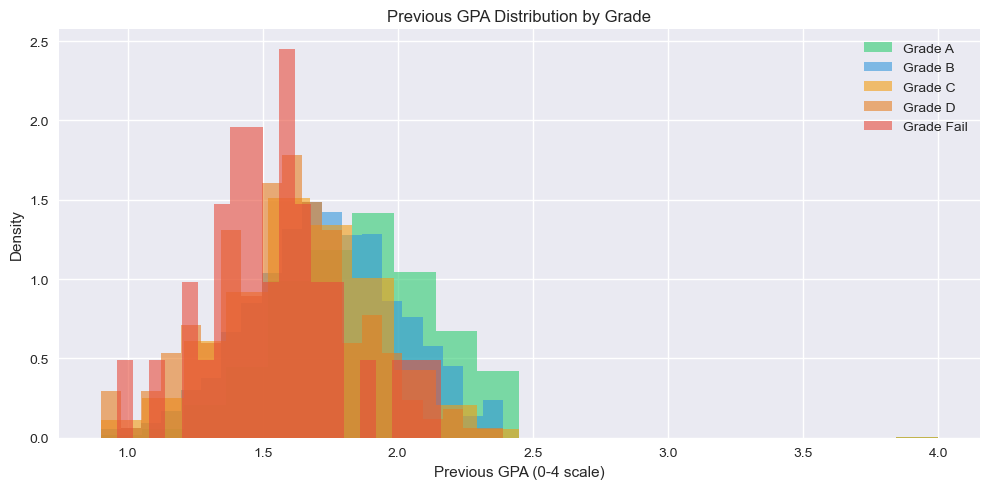

Fail students with Previous_GPA > 2.0: 3
Fail students with Previous_GPA <= 2.0: 31

All Fail student Previous_GPA values:
[1.35 1.51 0.96 1.41 1.64 1.45 1.43 2.01 1.59 1.09 1.49 1.55 1.4  2.08
 1.75 1.71 1.46 1.62 1.72 1.23 1.6  1.56 1.8  1.62 1.24 1.9  1.34 2.16
 1.36 1.49 1.43 1.59 1.27 1.58]


In [30]:
# Check Previous_GPA distribution across grade categories
print("=== Previous_GPA STATISTICS BY GRADE ===\n")

for grade in ['A', 'B', 'C', 'D', 'Fail']:
    subset = df_grade[df_grade['Grade'] == grade]['Previous_GPA']
    print(f"Grade {grade} (n={len(subset)}):")
    print(f"  Mean:   {subset.mean():.3f}")
    print(f"  Median: {subset.median():.3f}")
    print(f"  Std:    {subset.std():.3f}")
    print(f"  Min:    {subset.min():.3f}")
    print(f"  Max:    {subset.max():.3f}")
    print()

# Visualise
plt.figure(figsize=(10, 5))
grade_order = ['A', 'B', 'C', 'D', 'Fail']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']

for i, (grade, color) in enumerate(zip(grade_order, colors)):
    subset = df_grade[df_grade['Grade'] == grade]['Previous_GPA']
    plt.hist(subset, bins=20, alpha=0.6, label=f'Grade {grade}', 
             color=color, density=True)

plt.xlabel('Previous GPA (0-4 scale)')
plt.ylabel('Density')
plt.title('Previous GPA Distribution by Grade')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/previous_gpa_by_grade.png', dpi=150, bbox_inches='tight')
plt.show()

# Also check how many Fail students have GPA above 2.0
fail_students = df_grade[df_grade['Grade'] == 'Fail']
print(f"Fail students with Previous_GPA > 2.0: {len(fail_students[fail_students['Previous_GPA'] > 2.0])}")
print(f"Fail students with Previous_GPA <= 2.0: {len(fail_students[fail_students['Previous_GPA'] <= 2.0])}")
print(f"\nAll Fail student Previous_GPA values:")
print(fail_students['Previous_GPA'].values)

In [31]:
# model training (using linear regression, decision tree, and RandomForest algorithms)

Training Logistic Regression...
✅ Training complete!
✅ Predictions made on 1600 test students

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 74.5%

Classification Report:
              precision    recall  f1-score   support

           A       0.90      0.86      0.88       895
           B       0.60      0.64      0.62       442
           C       0.55      0.53      0.54       211
           D       0.41      0.44      0.43        45
        Fail       0.22      0.57      0.32         7

    accuracy                           0.74      1600
   macro avg       0.54      0.61      0.56      1600
weighted avg       0.75      0.74      0.75      1600



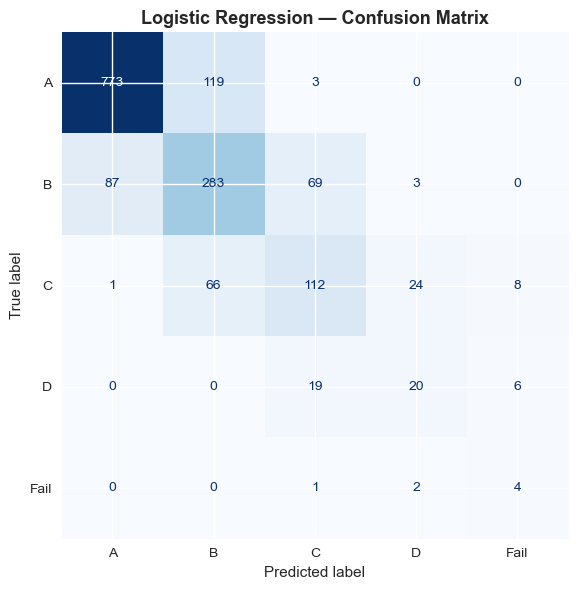

In [32]:
# ============================================================
# MODEL TRAINING — Logistic regression ALGORITHMS
# ============================================================
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Define the model
lr_model = LogisticRegression(
    max_iter=1000,       # try up to 1000 times to improve
    random_state=42      # same results every run
)

# Step 2: Train the model
print("Training Logistic Regression...")
lr_model.fit(X_train_balanced, y_train_balanced)
print("✅ Training complete!")

# Step 3: Predict on test data
y_pred_lr = lr_model.predict(X_test_scaled)
print(f"✅ Predictions made on {len(y_pred_lr)} test students")

# Step 4: Evaluate
grade_classes = ['A', 'B', 'C', 'D', 'Fail']
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy: {round(accuracy_lr * 100, 2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=grade_classes))

# Step 5: Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=grade_classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/09_lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Training Decision Tree...
✅ Training complete!
✅ Predictions made on 1600 test students

=== DECISION TREE RESULTS ===
Accuracy: 63.0%

Classification Report:
              precision    recall  f1-score   support

           A       0.87      0.74      0.80       895
           B       0.46      0.51      0.48       442
           C       0.39      0.51      0.44       211
           D       0.22      0.38      0.28        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.63      1600
   macro avg       0.39      0.43      0.40      1600
weighted avg       0.67      0.63      0.65      1600



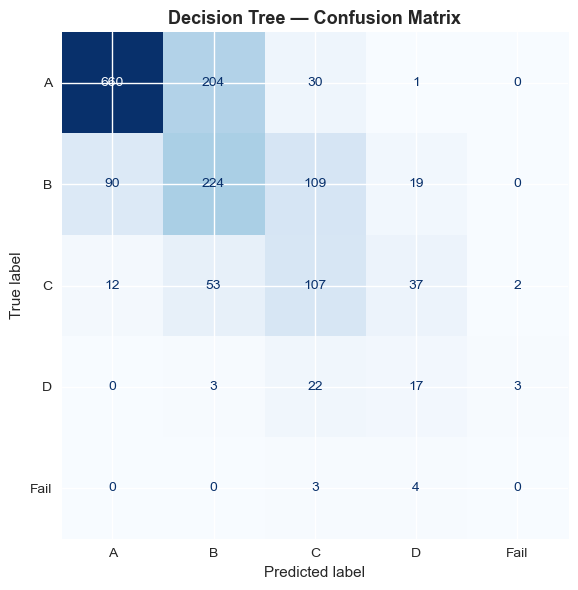

In [33]:
# ============================================================
# MODEL 2: DECISION TREE
# ============================================================
from sklearn.tree import DecisionTreeClassifier

# Step 1: Define
dt_model = DecisionTreeClassifier(
    criterion='gini',    # measure of impurity used to split nodes
    max_depth=10,        # maximum depth of tree (prevents overfitting)
    random_state=42
)

# Step 2: Train
print("Training Decision Tree...")
dt_model.fit(X_train_balanced, y_train_balanced)
print("✅ Training complete!")

# Step 3: Predict
y_pred_dt = dt_model.predict(X_test_scaled)
print(f"✅ Predictions made on {len(y_pred_dt)} test students")

# Step 4: Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"\n=== DECISION TREE RESULTS ===")
print(f"Accuracy: {round(accuracy_dt * 100, 2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_dt, target_names=grade_classes))

# Step 5: Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=grade_classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Decision Tree — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/10_dt_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Training Random Forest (100 trees)...
This may take 1-3 minutes on your laptop...
✅ Training complete in 3.51 seconds!
✅ Predictions made on 1600 test students

=== RANDOM FOREST RESULTS ===
Accuracy: 71.25%

Classification Report:
              precision    recall  f1-score   support

           A       0.85      0.89      0.87       895
           B       0.56      0.52      0.54       442
           C       0.48      0.50      0.49       211
           D       0.32      0.22      0.26        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.71      1600
   macro avg       0.44      0.43      0.43      1600
weighted avg       0.70      0.71      0.71      1600



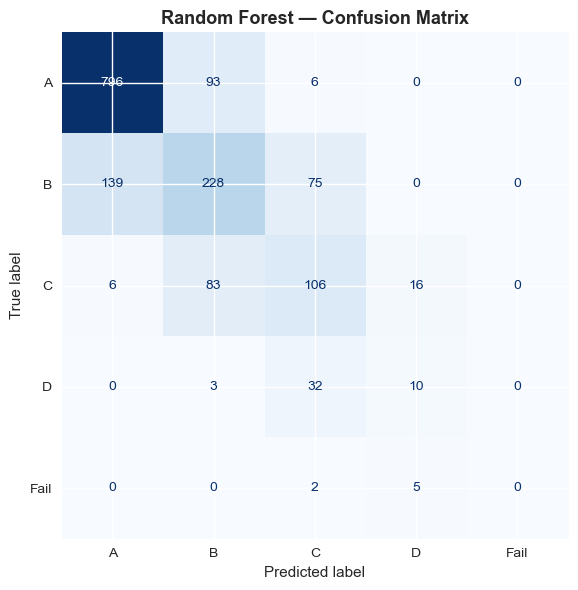


=== FEATURE IMPORTANCE (Top 15) ===
Rank   Feature                               Importance
-------------------------------------------------------
1      Hours_Studied                            13.62%
2      Tutoring_Sessions_Per_Week               10.21%
3      Exam_Anxiety_Score                        9.56%
4      Stress_Level                              6.18%
5      Previous_GPA                               5.5%
6      Motivation_Level                          4.59%
7      Screen_Time                               4.12%
8      Attendance                                4.03%
9      Psychological_State                       4.01%
10     Sleep_Hours                                3.9%
11     Diet_Quality                              3.17%
12     Community_Beliefs                         3.16%
13     Electricity_Availability                  2.97%
14     Family_Support                            2.73%
15     Home_Study_Environment                    2.71%


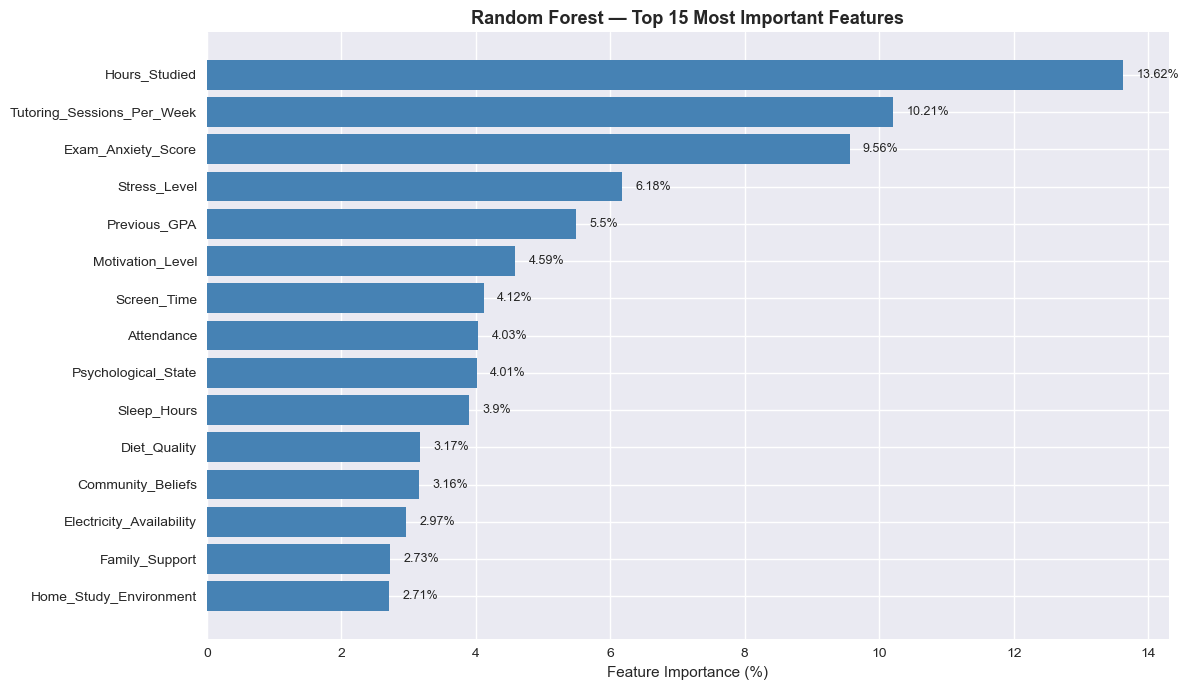

In [34]:
# ============================================================
# MODEL 3: RANDOM FOREST
# ============================================================
from sklearn.ensemble import RandomForestClassifier
import time

# Step 1: Define
rf_model = RandomForestClassifier(
    n_estimators=100,    # number of trees in the forest
    criterion='gini',    # measure of impurity for splitting
    random_state=42,
    n_jobs=-1            # use all CPU cores to speed up training
)

# Step 2: Train
print("Training Random Forest (100 trees)...")
print("This may take 1-3 minutes on your laptop...")
start = time.time()
rf_model.fit(X_train_balanced, y_train_balanced)
duration = round(time.time() - start, 2)
print(f"✅ Training complete in {duration} seconds!")

# Step 3: Predict
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"✅ Predictions made on {len(y_pred_rf)} test students")

# Step 4: Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"\n=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {round(accuracy_rf * 100, 2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=grade_classes))

# Step 5: Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=grade_classes)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/11_rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 6: Feature Importance (unique to Random Forest)
print("\n=== FEATURE IMPORTANCE (Top 15) ===")
feature_names = X_test_scaled.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print(f"{'Rank':<6} {'Feature':<35} {'Importance':>12}")
print("-" * 55)
for rank, idx in enumerate(indices[:15], 1):
    print(f"{rank:<6} {feature_names[idx]:<35} {round(importances[idx]*100, 2):>10}%")

# Feature importance chart
plt.figure(figsize=(12, 7))
top15_names = [feature_names[i] for i in indices[:15]]
top15_values = [importances[i] * 100 for i in indices[:15]]

bars = plt.barh(range(15), top15_values[::-1], color='steelblue')
plt.yticks(range(15), top15_names[::-1])
plt.xlabel('Feature Importance (%)')
plt.title('Random Forest — Top 15 Most Important Features',
          fontweight='bold', fontsize=13)
for bar, val in zip(bars, top15_values[::-1]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{round(val, 2)}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

RANDOM FOREST HYPERPARAMETER TUNING
Using RandomizedSearchCV — testing 20 random combinations
This will take approximately 5-15 minutes...

Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Search complete in 187.49 seconds!

Best parameters found:
  n_estimators: 200
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: None

Best cross-validation F1-Macro: 92.38%

=== TUNED RANDOM FOREST RESULTS ===
Accuracy: 72.31%

Classification Report:
              precision    recall  f1-score   support

           A       0.84      0.90      0.87       895
           B       0.57      0.53      0.55       442
           C       0.51      0.50      0.51       211
           D       0.43      0.29      0.35        45
        Fail       0.00      0.00      0.00         7

    accuracy                           0.72      1600
   macro avg       0.47      0.44      0.45      1600
weighted avg       0.71      0.72      0.72      1600


=== IMPROVEMENT COMPARISO

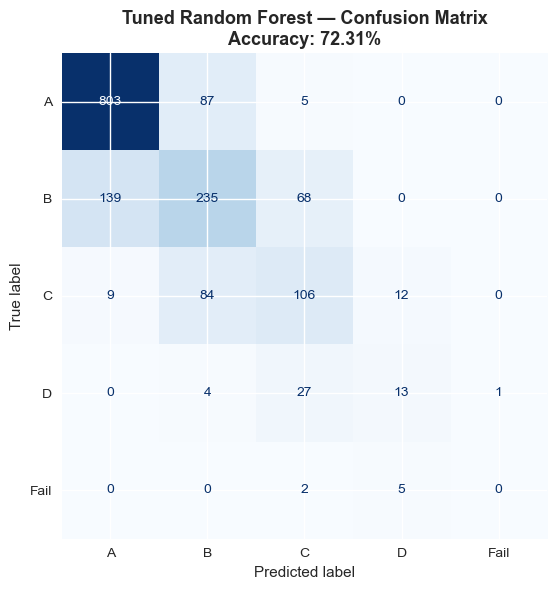


✅ Tuned Random Forest complete!


In [35]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("=" * 60)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 60)
print("Using RandomizedSearchCV — testing 20 random combinations")
print("This will take approximately 5-15 minutes...\n")

# Parameter grid to search
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

# Base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Randomized search
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,              # try 20 random combinations
    cv=3,                   # 3-fold cross validation
    scoring='f1_macro',     # optimise for macro F1 (fair across all grades)
    random_state=42,
    n_jobs=-1,              # use all CPU cores
    verbose=1               # show progress
)

start = time.time()
rf_search.fit(X_train_balanced, y_train_balanced)
duration = round(time.time() - start, 2)

print(f"\n✅ Search complete in {duration} seconds!")
print(f"\nBest parameters found:")
for param, value in rf_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation F1-Macro: {round(rf_search.best_score_*100, 2)}%")

# Train final model with best parameters
rf_tuned = rf_search.best_estimator_

# Predict and evaluate
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
accuracy_rf_tuned = accuracy_score(y_test, y_pred_rf_tuned)

print(f"\n=== TUNED RANDOM FOREST RESULTS ===")
print(f"Accuracy: {round(accuracy_rf_tuned * 100, 2)}%")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=grade_classes))

# Compare with original
print(f"\n=== IMPROVEMENT COMPARISON ===")
print(f"{'Metric':<20} {'Original RF':>15} {'Tuned RF':>15} {'Change':>10}")
print("-" * 62)

orig_acc = round(accuracy_rf * 100, 2)
tuned_acc = round(accuracy_rf_tuned * 100, 2)
change_acc = round(tuned_acc - orig_acc, 2)

from sklearn.metrics import f1_score
orig_f1 = round(f1_score(y_test, y_pred_rf, average='macro')*100, 2)
tuned_f1 = round(f1_score(y_test, y_pred_rf_tuned, average='macro')*100, 2)
change_f1 = round(tuned_f1 - orig_f1, 2)

print(f"{'Accuracy':<20} {orig_acc:>14}% {tuned_acc:>14}% {change_acc:>+9}%")
print(f"{'F1 Macro':<20} {orig_f1:>14}% {tuned_f1:>14}% {change_f1:>+9}%")

# Confusion Matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_tuned,
    display_labels=grade_classes
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Tuned Random Forest — Confusion Matrix\nAccuracy: {tuned_acc}%',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/13_rf_tuned_confusion_matrix.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Tuned Random Forest complete!")

FINAL MODEL COMPARISON — ALL TRAINED MODELS

Model                       Accuracy   F1 Macro  F1 Weighted   Precision   Recall  Fail Recall
--------------------------------------------------------------------------------------------
Logistic Regression            74.5%     55.75%       74.88%      75.41%    74.5%       57.14%
Decision Tree                  63.0%     40.02%       64.56%      67.05%    63.0%         0.0%
Random Forest                 71.25%     43.16%       70.55%      70.03%   71.25%         0.0%
Tuned Random Forest           72.31%     45.49%       71.55%      71.01%   72.31%         0.0%

BEST MODEL: Logistic Regression with 74.5% accuracy


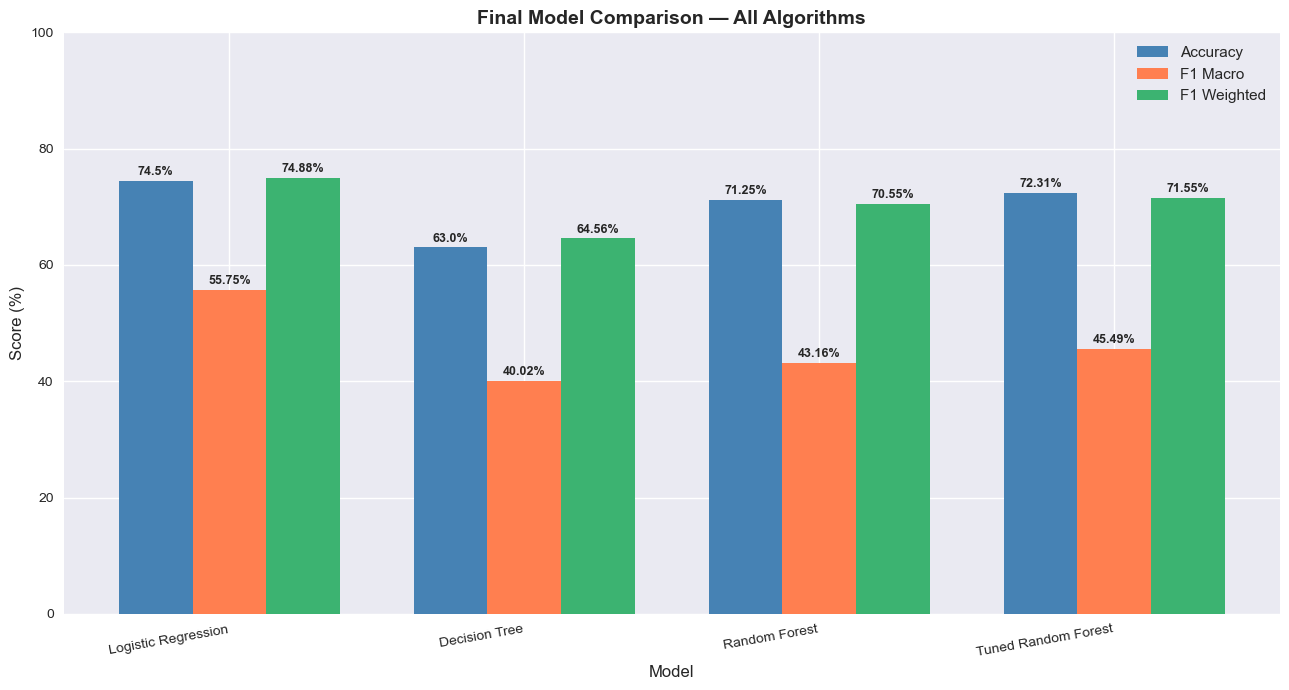


✅ Model comparison complete!
✅ Chart saved


In [36]:
# ============================================================
# FINAL MODEL COMPARISON SUMMARY
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("FINAL MODEL COMPARISON — ALL TRAINED MODELS")
print("=" * 70)

# All predictions already made
all_models = {
    'Logistic Regression':  y_pred_lr,
    'Decision Tree':        y_pred_dt,
    'Random Forest':        y_pred_rf,
    'Tuned Random Forest':  y_pred_rf_tuned,
}

# Collect metrics
comparison = []
for name, y_pred in all_models.items():
    acc        = round(accuracy_score(y_test, y_pred) * 100, 2)
    f1_macro   = round(f1_score(y_test, y_pred, average='macro') * 100, 2)
    f1_weighted= round(f1_score(y_test, y_pred, average='weighted') * 100, 2)
    precision  = round(precision_score(y_test, y_pred, average='weighted',
                                       zero_division=0) * 100, 2)
    recall     = round(recall_score(y_test, y_pred, average='weighted',
                                    zero_division=0) * 100, 2)
    fail_recall= round(recall_score(y_test, y_pred, 
                                    labels=[4], average='micro',
                                    zero_division=0) * 100, 2)
    comparison.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Macro': f1_macro,
        'F1 Weighted': f1_weighted,
        'Precision': precision,
        'Recall': recall,
        'Fail Recall': fail_recall
    })

# Print table
print(f"\n{'Model':<25} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>12} {'Precision':>11} {'Recall':>8} {'Fail Recall':>12}")
print("-" * 92)
for row in comparison:
    print(f"{row['Model']:<25} {row['Accuracy']:>9}% {row['F1 Macro']:>9}% "
          f"{row['F1 Weighted']:>11}% {row['Precision']:>10}% "
          f"{row['Recall']:>7}% {row['Fail Recall']:>11}%")

# Determine best model
best = max(comparison, key=lambda x: x['Accuracy'])
print(f"\n{'='*70}")
print(f"BEST MODEL: {best['Model']} with {best['Accuracy']}% accuracy")
print(f"{'='*70}")

# ── COMPARISON CHART ──────────────────────────────────────────
model_names  = [r['Model'] for r in comparison]
accuracies   = [r['Accuracy'] for r in comparison]
f1_macros    = [r['F1 Macro'] for r in comparison]
f1_weighteds = [r['F1 Weighted'] for r in comparison]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 7))
bars1 = ax.bar(x - width, accuracies,   width, label='Accuracy',    color='steelblue')
bars2 = ax.bar(x,         f1_macros,    width, label='F1 Macro',    color='coral')
bars3 = ax.bar(x + width, f1_weighteds, width, label='F1 Weighted', color='mediumseagreen')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Final Model Comparison — All Algorithms',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/16_final_model_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model comparison complete!")
print("✅ Chart saved")

In [37]:
# ============================================================
# SAVE BEST MODEL AND SUPPORTING OBJECTS
# ============================================================
import joblib
import os

print("=" * 55)
print("SAVING BEST MODEL TO models/ FOLDER")
print("=" * 55)

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save best model (Logistic Regression)
joblib.dump(lr_model, '../models/best_model.pkl')
print("✅ best_model.pkl saved (Logistic Regression)")

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ scaler.pkl saved")

# Save label encoder
joblib.dump(label_encoder, '../models/label_encoder.pkl')
print("✅ label_encoder.pkl saved")

# Save feature names (needed by web app to order inputs correctly)
feature_names = X_test_scaled.columns.tolist()
joblib.dump(feature_names, '../models/feature_names.pkl')
print("✅ feature_names.pkl saved")

# Verify all files saved correctly
print(f"\n=== FILES IN models/ FOLDER ===")
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}')
    print(f"  {f:<30} {round(size/1024, 2)} KB")

# Test: reload and predict one student
print(f"\n=== VERIFICATION — TEST RELOAD ===")
loaded_model   = joblib.load('../models/best_model.pkl')
loaded_scaler  = joblib.load('../models/scaler.pkl')
loaded_encoder = joblib.load('../models/label_encoder.pkl')

test_student = X_test_scaled.iloc[[0]]
prediction = loaded_model.predict(test_student)
grade = loaded_encoder.inverse_transform(prediction)[0]
actual = loaded_encoder.inverse_transform([y_test[0]])[0]

print(f"  Test student prediction: Grade {grade}")
print(f"  Actual grade:            Grade {actual}")
print(f"  Match: {'✅ Correct' if grade == actual else '❌ Wrong'}")

print(f"\n{'='*55}")
print(f"models/ FOLDER COMPLETE — READY FOR WEB APP")
print(f"{'='*55}")

SAVING BEST MODEL TO models/ FOLDER
✅ best_model.pkl saved (Logistic Regression)
✅ scaler.pkl saved
✅ label_encoder.pkl saved
✅ feature_names.pkl saved

=== FILES IN models/ FOLDER ===
  best_model.pkl                 2.83 KB
  feature_names.pkl              0.55 KB
  label_encoder.pkl              0.4 KB
  scaler.pkl                     1.72 KB

=== VERIFICATION — TEST RELOAD ===
  Test student prediction: Grade B
  Actual grade:            Grade B
  Match: ✅ Correct

models/ FOLDER COMPLETE — READY FOR WEB APP
